# Can we fit $Re[\mathcal{H}]$ Using DNNs at a Single Kinematic Point Using the KM15/BKM10 Formalism for the Cross-Section?

## (1): Initializing Requisite Code/Settings:

### (1.1): Import Libraries:

In [1]:
import math
import glob

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from iminuit import Minuit
from scipy.integrate import quad
from scipy.stats import norm
from sklearn.model_selection import train_test_split
import gepard as g
from gepard.fits import th_KM15
from gepard.bmk import BM10

from bkm10_lib.core import DifferentialCrossSection
from bkm10_lib.inputs import BKM10Inputs
from bkm10_lib.cff_inputs import CFFInputs

### (1.2): Matplotlib Plotting Aesthetics:

In [2]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 8.5
plt.rcParams['xtick.major.width'] = 0.5
plt.rcParams['xtick.minor.size'] = 2.5
plt.rcParams['xtick.minor.width'] = 0.5
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['ytick.major.size'] = 8.5
plt.rcParams['ytick.major.width'] = 0.5
plt.rcParams['ytick.minor.size'] = 2.5
plt.rcParams['ytick.minor.width'] = 0.5
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['ytick.right'] = True

### (1.3): TensorFlow Configurations:

In [3]:
_FLOATX = tf.float32

# below did NOT work for fixing the stupid tf type mismatch
# tf.keras.mixed_precision.set_global_policy('float32')

print(tf.config.list_physical_devices())
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print(tf.test.gpu_device_name())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
Num GPUs Available:  0
Num CPUs Available:  1



## (2): Generating Pseudodata:

### (2.0): Data Collection Definitions:

In [4]:
VERSION_NUMBER = 7
MINOR_NUMBER = 1
MAJOR_MINOR_NUMBER = f"{VERSION_NUMBER}_{MINOR_NUMBER}"

print(f"We are saving figures and data with the following appendage: {MAJOR_MINOR_NUMBER}")

We are saving figures and data with the following appendage: 7_1


### (2.1): Defining the Azimuthal Range:

In [5]:
STARTING_PHI_VALUE_IN_DEGREES = 0
ENDING_PHI_VALUE_IN_DEGREES = 360
NUMBER_OF_PHI_POINTS = 360
phi_array_in_degrees = np.linspace(
    start = STARTING_PHI_VALUE_IN_DEGREES,
    stop = ENDING_PHI_VALUE_IN_DEGREES,
    num = NUMBER_OF_PHI_POINTS)
phi_array_in_radians = [np.radians(degree_value) for degree_value in phi_array_in_degrees]

print(f"We have constructed a Python list of length {len(phi_array_in_radians)} of azimuthal angles from {STARTING_PHI_VALUE_IN_DEGREES} degrees to {ENDING_PHI_VALUE_IN_DEGREES} degrees.")

We have constructed a Python list of length 360 of azimuthal angles from 0 degrees to 360 degrees.


### (2.2): Defining the Kinematic Point:

#### (2.2.1): Required Kinematics

In [6]:
TEST_BEAM_ENERGY = 5.75
TEST_Q_SQUARED = 1.82
TEST_X_BJORKEN = 0.34
TEST_T_VALUE = -.17

# these values come later *and* are derived from the values above:
# see [this Mathematica notebook](https://github.com/Woofmagic/BKM10_Spin_Polarized/blob/main/mathematica/bkm10_test.nb)
TEST_EP = 0.47293561004973345
TEST_Y = 0.49609612355928445
TEST_XI = 0.19906188837146524
TEST_T_MIN = -0.13551824472915253
TEST_T_PRIME = -0.034481755270847486
TEST_K_TILDE = 0.1592415651944438
TEST_K = 0.08492693191323883
TEST_FE = 0.6511853266961825
TEST_FG = 1.8186612105254523
TEST_F2 = 1.1137103937669304
TEST_F1 = 0.7049508167585219
TEST_KDD = (
    (-1.*TEST_Q_SQUARED / (2.*TEST_Y*(1.+TEST_EP**2))) * 
    (1. + ((2.*TEST_K*tf.cos(tf.constant(np.pi)- phi_array_in_radians)) - ((TEST_T_VALUE / TEST_Q_SQUARED)*(1.-(TEST_X_BJORKEN * (2. - TEST_Y)) + (TEST_Y * TEST_EP**2 / 2.))) + (TEST_Y * TEST_EP**2 / 2.))))

TEST_P1 = (1. + (2. * (TEST_KDD / TEST_Q_SQUARED)))
TEST_P2 = ((-2. * (TEST_KDD / TEST_Q_SQUARED)) + (TEST_T_VALUE / TEST_Q_SQUARED))

#### (2.2.2): Required CFF Values

In [7]:
# these are test values ONLY! (i.e. not KM15 values)
TEST_REAL_CFF_H = -0.897
TEST_REAL_CFF_HT = 2.444
TEST_REAL_CFF_E = -0.541
TEST_REAL_CFF_ET = 2.207 
TEST_IM_CFF_H = 2.421
TEST_IM_CFF_HT = 1.131
TEST_IM_CFF_E = 0.903
TEST_IM_CFF_ET = 5.383

# WW-relations are on!!
TEST_REAL_CFF_H_EFF = -1.4961696451186222
TEST_REAL_CFF_HT_EFF = 4.0765201924971155
TEST_REAL_CFF_E_EFF = -0.9023721048039851
TEST_REAL_CFF_ET_EFF = 3.6812111558269773
TEST_IM_CFF_H_EFF = 4.038156868263304
TEST_IM_CFF_HT_EFF = 1.8864747699321758
TEST_IM_CFF_E_EFF = 1.5061774688317902
TEST_IM_CFF_ET_EFF = 8.978685841330593

#### (2.2.3): **DON'T FORGET**: Lepton Helicity and Target Polarization

In [8]:
TEST_LEPTON_HELICITY = 0.0
TEST_TARGET_POLARIZATION = 0.0

#### (2.2.4): Just Plotting the $\phi$-Sensitive Propagators to See if They're Coded Correctly

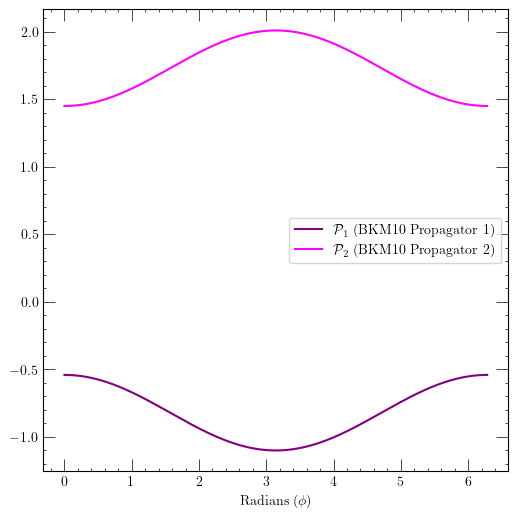

In [9]:
fig_props, ax_props = plt.subplots(1, 1, figsize = (6, 6))

ax_props.plot(phi_array_in_radians, TEST_P1, label = r"$\mathcal{P}_{1}$ (BKM10 Propagator 1)", color = "purple")
ax_props.plot(phi_array_in_radians, TEST_P2, label = r"$\mathcal{P}_{2}$ (BKM10 Propagator 2)", color = "magenta")

ax_props.set_xlabel(r'Radians ($\phi$)')

ax_props.legend()

### (2.3): Use the KM15 Model of $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ to Generate a True Value:

Uses `gepard`'s `DataPoint()` class to define the kinematic setting.

In [10]:
test_datapoints = [g.DataPoint(
    xB = TEST_X_BJORKEN, t = TEST_T_VALUE, Q2 = TEST_Q_SQUARED, phi = fixed_phi,
    process = "ep2epgamma", exptype = 'fixed target',
    in1energy = TEST_BEAM_ENERGY, in1charge = -1, in1polarization = +1,
    observable = 'XS',
    fname = 'Trento') for fixed_phi in phi_array_in_radians]

#### (2.3.1): Check out the Length of the Datapoint Array:

These arrays should have exactly the same length without absolutely any difference.

In [11]:
len(test_datapoints) == len(phi_array_in_radians)

True

### (2.4): Evaluate $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ using KM15 for the Datapoints 

In [12]:
# cff H
real_h_values = [th_KM15.ReH(datapoint) for datapoint in test_datapoints]
imag_h_values = [th_KM15.ImH(datapoint) for datapoint in test_datapoints]

# cff E
real_e_values = [th_KM15.ReE(datapoint) for datapoint in test_datapoints]
imag_e_values = [th_KM15.ImE(datapoint) for datapoint in test_datapoints]

# cff Ht
real_ht_values = [th_KM15.ReHt(datapoint) for datapoint in test_datapoints]
imag_ht_values = [th_KM15.ImHt(datapoint) for datapoint in test_datapoints]

# cff Et
real_et_values = [th_KM15.ReEt(datapoint) for datapoint in test_datapoints]
imag_et_values = [th_KM15.ImEt(datapoint) for datapoint in test_datapoints]

#### (2.4.1): Check out the Length of the CFF Data Array:

These arrays should ALSO be of exactly the same length --- For every phi, we have a kinematic point, and every kinematic point will have a CFF value.

In [13]:
print(len(real_h_values) == len(test_datapoints))
print(len(imag_h_values) == len(test_datapoints))

True
True


#### (2.4.2): See Some Values in the CFF Arrays:

High degree of redundancy expected; kinematics don't change, ergo CFFs don't change.

In [14]:
real_h_values

[-2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.4490177469911387,
 -2.449017

### (2.5): Use the [BKM10 Library](https://pypi.org/project/bkm10/) to Predict the Cross-Section

#### (2.5.1): Define the CFF Values --- **Very Important!!**

Note that at the specific kinematic settings of
```python
TEST_BEAM_ENERGY = 5.75
TEST_Q_SQUARED = 1.82
TEST_X_BJORKEN = 0.34
TEST_T_VALUE = -.17
```
one can use the following configuration of the 8 CFFs according to [Higher-order kinematical effects in deeply virtual Compton scattering](https://link.springer.com/article/10.1007/JHEP12(2021)103) --- See Table 1
```python
CFF_H_KM15 = complex(-0.897, 2.421)
CFF_H_TILDE_KM15 = complex(2.444, 1.131)
CFF_E_KM15 = complex(-0.541, 0.903)
CFF_E_TILDE_KM15 = complex(2.207, 5.383)
```

So, **please understand** that what we will do is **change only the `CFF_H_KM15` values** in accordance with what the KM15 model predicts and leave **all the other CFFs the same**!

In [15]:
# we slice at [0] because, as we verified earlier, these arrays are all the same value; equivalence class defined on them

print(f"Now setting Re[H] = {real_h_values[0]}")
print(f"Now setting Im[H] = {imag_h_values[0]}")

print(f"Now setting Re[H] = {real_e_values[0]}")
print(f"Now setting Im[E] = {imag_e_values[0]}")

print(f"Now setting Re[Ht] = {real_ht_values[0]}")
print(f"Now setting Im[Ht] = {imag_ht_values[0]}")

print(f"Now setting Re[Et] = {real_et_values[0]}")
print(f"Now setting Im[Et] = {imag_et_values[0]}")

CFF_REAL_H_KM15 = real_h_values[0]
CFF_IMAG_H_KM15 = imag_h_values[0]
CFF_REAL_E_KM15 = real_e_values[0]
CFF_IMAG_E_KM15 = imag_e_values[0]
CFF_REAL_HT_KM15 = real_ht_values[0]
CFF_IMAG_HT_KM15 = imag_ht_values[0]
CFF_REAL_ET_KM15 = real_et_values[0]
CFF_IMAG_ET_KM15 = imag_et_values[0]

CFF_H_KM15 = complex(CFF_REAL_H_KM15, CFF_IMAG_H_KM15)
CFF_H_TILDE_KM15 = complex(CFF_REAL_HT_KM15, CFF_IMAG_HT_KM15)
CFF_E_KM15 = complex(CFF_REAL_E_KM15, CFF_IMAG_E_KM15)
CFF_E_TILDE_KM15 = complex(CFF_REAL_ET_KM15, CFF_IMAG_ET_KM15)

Now setting Re[H] = -2.4490177469911387
Now setting Im[H] = 3.481649173751274
Now setting Re[H] = 2.217354372014208
Now setting Im[E] = 0.0
Now setting Re[Ht] = 1.4093937264544776
Now setting Im[Ht] = 1.5773644025601397
Now setting Re[Et] = 144.4101642020152
Now setting Im[Et] = 0.0


#### (2.5.2): Use the BKM10 Library to Evaluate the Cross-Section as a Function of $\phi$

##### (2.5.2.1): Cross-Section Values using **KM15** CFFs:

In [16]:
cross_section_km15 = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = TEST_BEAM_ENERGY,
            squared_Q_momentum_transfer = TEST_Q_SQUARED,
            x_Bjorken = TEST_X_BJORKEN,
            squared_hadronic_momentum_transfer_t = TEST_T_VALUE),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = CFF_H_KM15,
            compton_form_factor_h_tilde = CFF_H_TILDE_KM15,
            compton_form_factor_e = CFF_E_KM15,
            compton_form_factor_e_tilde = CFF_E_TILDE_KM15),
        "target_polarization": 0.0,
        "lepton_beam_polarization": 0.0,
        "using_ww": True
    },
    verbose = False,
    debugging = False)

bkm10_cross_sections_km15 = cross_section_km15.compute_cross_section(phi_array_in_radians).real
bkm10_bsa_km15 = cross_section_km15.compute_bsa(phi_array_in_radians).real

##### (2.5.2.2): Cross-Section Values using **XDJ** CFFs:

[NOTE]: The "XDJ CFFs" come from the paper we cited earlier: [Higher-order kinematical effects in deeply virtual Compton scattering](https://link.springer.com/article/10.1007/JHEP12(2021)103).

[NOTE]: We no longer use the XDJ CFF values to plot because all we're concerned about in this approach is trying to match the KM15 values.

In [17]:
cross_section_xdj = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = TEST_BEAM_ENERGY,
            squared_Q_momentum_transfer = TEST_Q_SQUARED,
            x_Bjorken = TEST_X_BJORKEN,
            squared_hadronic_momentum_transfer_t = TEST_T_VALUE),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = complex(TEST_REAL_CFF_H, TEST_IM_CFF_H),
            compton_form_factor_h_tilde = complex(TEST_REAL_CFF_HT, TEST_IM_CFF_HT),
            compton_form_factor_e = complex(TEST_REAL_CFF_E, TEST_IM_CFF_E),
            compton_form_factor_e_tilde = complex(TEST_REAL_CFF_ET, TEST_IM_CFF_ET)),
        "target_polarization": 0.0,
        "lepton_beam_polarization": 0.0,
        "using_ww": True
    },
    verbose = False,
    debugging = False)

bkm10_cross_sections_xdj = cross_section_xdj.compute_cross_section(phi_array_in_radians).real
bkm10_bsa_xdj = cross_section_xdj.compute_bsa(phi_array_in_radians).real

#### (2.5.3): Plotting Cross-Section Data:

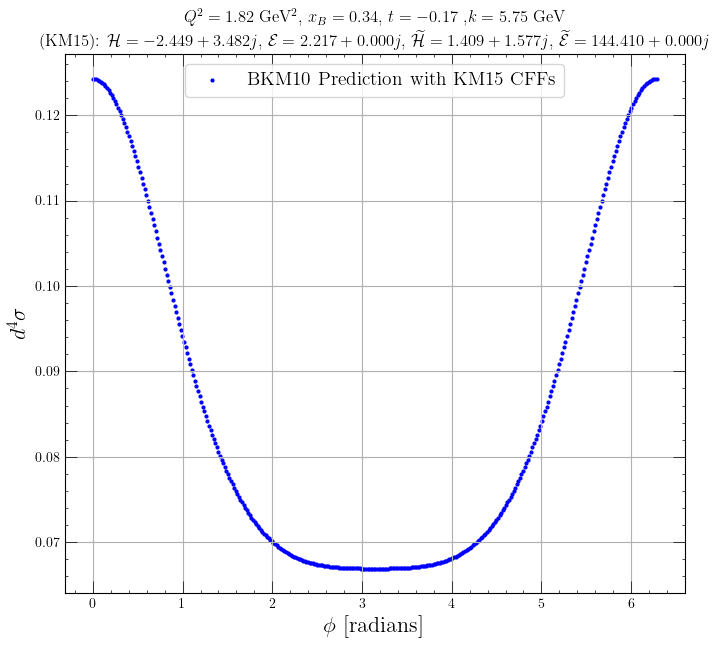

In [107]:
cross_section_fig, cross_section_axes = plt.subplots(1, figsize = (8, 7))

cross_section_axes.scatter(
    phi_array_in_radians, bkm10_cross_sections_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

# cross_section_axes.scatter(
#     phi_array_in_radians, bkm10_cross_sections_xdj,
#     s = 4., label = "BKM10 Prediction with XDJ CFFs", color = "skyblue")

title_string = (
    rf"$Q^2 = {TEST_Q_SQUARED:.2f}$ GeV$^2$, "
    rf"$x_B = {TEST_X_BJORKEN:.2f}$, "
    rf"$t = {TEST_T_VALUE:.2f}$ ,"
    rf"$k = {TEST_BEAM_ENERGY:.2f}$ GeV"
)

km15_cff_string = (
    rf"$\mathcal{{H}} = {CFF_H_KM15:.3f}$, "
    rf"$\mathcal{{E}} = {CFF_E_KM15:.3f}$, "
    rf"$\widetilde{{\mathcal{{H}}}} = {CFF_H_TILDE_KM15:.3f}$, "
    rf"$\widetilde{{\mathcal{{E}}}} = {CFF_E_TILDE_KM15:.3f}$ "
)

xdj_cff_string = (
    rf"$\mathcal{{H}} = {complex(TEST_REAL_CFF_H, TEST_IM_CFF_H):.3f}$, "
    rf"$\mathcal{{E}} = {complex(TEST_REAL_CFF_E, TEST_IM_CFF_E):.3f}$, "
    rf"$\widetilde{{\mathcal{{H}}}} = {complex(TEST_REAL_CFF_HT, TEST_IM_CFF_HT):.3f}$, "
    rf"$\widetilde{{\mathcal{{E}}}} = {complex(TEST_REAL_CFF_ET, TEST_IM_CFF_ET):.3f}$ "
)

cross_section_axes.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
cross_section_axes.set_ylabel(r"$d^{4}\sigma$", fontsize = 16)
cross_section_axes.set_title(f"{title_string}\n(KM15): {km15_cff_string}")
# cross_section_axes.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")

cross_section_axes.legend(fontsize = 14)

cross_section_axes.grid(visible = True)

#### (2.5.4): Plotting BSA Data:

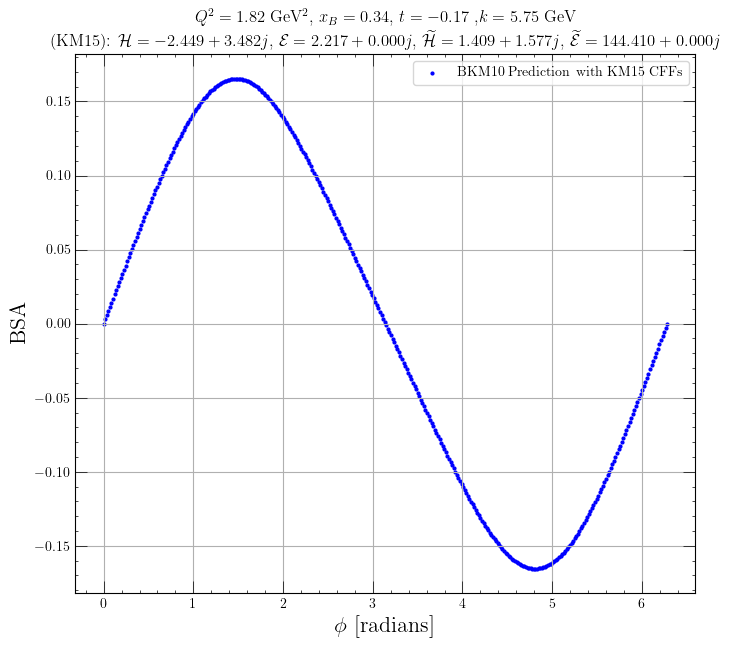

In [ ]:
bsa_fig, bsa_axes = plt.subplots(1, figsize = (8, 7))

bsa_axes.scatter(
    phi_array_in_radians, bkm10_bsa_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

# bsa_axes.scatter(
#     phi_array_in_radians, bkm10_bsa_xdj,
#     s = 4., label = "BKM10 Prediction with XDJ CFFs", color = "skyblue")

title_string = (
    rf"$Q^2 = {TEST_Q_SQUARED:.2f}$ GeV$^2$, "
    rf"$x_B = {TEST_X_BJORKEN:.2f}$, "
    rf"$t = {TEST_T_VALUE:.2f}$ ,"
    rf"$k = {TEST_BEAM_ENERGY:.2f}$ GeV"
)

km15_cff_string = (
    rf"$\mathcal{{H}} = {CFF_H_KM15:.3f}$, "
    rf"$\mathcal{{E}} = {CFF_E_KM15:.3f}$, "
    rf"$\widetilde{{\mathcal{{H}}}} = {CFF_H_TILDE_KM15:.3f}$, "
    rf"$\widetilde{{\mathcal{{E}}}} = {CFF_E_TILDE_KM15:.3f}$ "
)

xdj_cff_string = (
    rf"$\mathcal{{H}} = {complex(TEST_REAL_CFF_H, TEST_IM_CFF_H):.3f}$, "
    rf"$\mathcal{{E}} = {complex(TEST_REAL_CFF_E, TEST_IM_CFF_E):.3f}$, "
    rf"$\widetilde{{\mathcal{{H}}}} = {complex(TEST_REAL_CFF_HT, TEST_IM_CFF_HT):.3f}$, "
    rf"$\widetilde{{\mathcal{{E}}}} = {complex(TEST_REAL_CFF_ET, TEST_IM_CFF_ET):.3f}$ "
)

bsa_axes.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
bsa_axes.set_ylabel(r"BSA", fontsize = 16)
bsa_axes.set_title(f"{title_string}\n(KM15): {km15_cff_string}")
# bsa_axes.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")

bsa_axes.legend(fontsize = 14)

bsa_axes.grid(visible = True)

### (2.6): Piece Together Fixed Kinematic Settings, Varying Phi Data, and CFF Data into Pandas DataFrame:

In [20]:
test_dataframe = pd.DataFrame({
    "set": 1,
    "k": TEST_BEAM_ENERGY,
    "q_squared": TEST_Q_SQUARED,
    "x_b": TEST_X_BJORKEN,
    "t": TEST_T_VALUE,
    "phi": phi_array_in_radians,
    "cross_section": bkm10_cross_sections_km15, # IMPORTANT! We are using the KM15-predicted x-section here!
    "beam_spin_asymmetry": bkm10_bsa_km15,
    "Re[H]": real_h_values, # KM15 value for Re[H]
    "Im[H]": imag_h_values # KM15 value for Im[H]
})

#### (2.6.1): Checking Out the DataFrame with the Pseudodata:

In [21]:
test_dataframe.head()

,set,k,q_squared,x_b,t,phi,cross_section,beam_spin_asymmetry,Re[H],Im[H]
0,1,5.75,1.82,0.34,-0.17,0.000000,0.124287,0.000000,-2.449018,3.481649
1,1,5.75,1.82,0.34,-0.17,0.017502,0.124273,0.002815,-2.449018,3.481649
2,1,5.75,1.82,0.34,-0.17,0.035004,0.124232,0.005630,-2.449018,3.481649
3,1,5.75,1.82,0.34,-0.17,0.052506,0.124164,0.008444,-2.449018,3.481649
4,1,5.75,1.82,0.34,-0.17,0.070008,0.124068,0.011256,-2.449018,3.481649


## (3): Data Preprocessing:

### (3.1): Define What Becomes the $x$ and $y$ Data:

**Important**: Define here what you want to train on!

In [22]:
x_data = test_dataframe[["t", "x_b", "q_squared", "phi"]]
y_data = test_dataframe[["cross_section","beam_spin_asymmetry"]]

#### (3.1.1): Let's Check Out the $x$ DF:

In [23]:
x_data.head()

,t,x_b,q_squared,phi
0,-0.17,0.34,1.82,0.000000
1,-0.17,0.34,1.82,0.017502
2,-0.17,0.34,1.82,0.035004
3,-0.17,0.34,1.82,0.052506
4,-0.17,0.34,1.82,0.070008


#### (3.1.2): Let's Check Out the $y$ DF:

In [24]:
y_data.head()

,cross_section,beam_spin_asymmetry
0,0.124287,0.000000
1,0.124273,0.002815
2,0.124232,0.005630
3,0.124164,0.008444
4,0.124068,0.011256


### (3.2): Train-Test Split Here:

#### (3.2.1): Define the Partition Percentages Here (Train/Validate/Test):

In [25]:
TOTAL_DATA_SIZE = len(x_data)
print(f"Total data size is: {TOTAL_DATA_SIZE}")

_DNN_TRAINING_TEMPORARY_SPLIT_PERCENTAGE = 0.1
_DNN_VALIDATION_TESTING_SPLIT_PERCENTAGE = 0.1

number_of_dnn_temporary_points = int(np.ceil(TOTAL_DATA_SIZE * _DNN_TRAINING_TEMPORARY_SPLIT_PERCENTAGE))
number_of_dnn_testing_points = int(np.ceil(number_of_dnn_temporary_points * _DNN_VALIDATION_TESTING_SPLIT_PERCENTAGE))
number_of_dnn_validation_points = number_of_dnn_temporary_points - number_of_dnn_testing_points
number_of_dnn_training_points = TOTAL_DATA_SIZE - number_of_dnn_validation_points - number_of_dnn_testing_points

print(f"[NOTE]: Train/Validation Split is {_DNN_TRAINING_TEMPORARY_SPLIT_PERCENTAGE * 100}%, giving {number_of_dnn_validation_points} validation points (with ceiling).")
print(f"[NOTE]: Validation/Test Split is {_DNN_VALIDATION_TESTING_SPLIT_PERCENTAGE * 100}%, giving {number_of_dnn_testing_points} testing points (with ceiling).")
print(f"Remaining training data points are: {number_of_dnn_training_points}")

Total data size is: 360
[NOTE]: Train/Validation Split is 10.0%, giving 32 validation points (with ceiling).
[NOTE]: Validation/Test Split is 10.0%, giving 4 testing points (with ceiling).
Remaining training data points are: 324


#### (3.2.2): First Split: Split Entire Data into Training and *Temporary*:

In [26]:
x_training, x_remaining, y_training, y_remaining = train_test_split(
    x_data,
    y_data,
    test_size = _DNN_TRAINING_TEMPORARY_SPLIT_PERCENTAGE,
    shuffle = True)

#### (3.2.3): Second Split: Split *Temporary* Data into Validation and Testing:

In [27]:
x_validation, x_testing, y_validation, y_testing = train_test_split(
    x_remaining,
    y_remaining,
    test_size = _DNN_VALIDATION_TESTING_SPLIT_PERCENTAGE,
    shuffle = True)

### (3.3): What does the pre-processed data look like?

#### (3.3.1): Training $x$ Features:

In [28]:
print(f"Size of x training: {len(x_training)}")
print(f"Does it match with what's expected? {len(x_training) == number_of_dnn_training_points}")

x_training.head()

Size of x training: 324
Does it match with what's expected? True


,t,x_b,q_squared,phi
46,-0.17,0.34,1.82,0.805088
93,-0.17,0.34,1.82,1.627678
97,-0.17,0.34,1.82,1.697685
178,-0.17,0.34,1.82,3.115340
176,-0.17,0.34,1.82,3.080336


#### (3.3.2): Training $y$ Labels:

In [29]:
print(f"Size of y training: {len(y_training)}")
print(f"Does it match with what's expected? {len(y_training) == number_of_dnn_training_points}")

y_training.head()

Size of y training: 324
Does it match with what's expected? True


,cross_section,beam_spin_asymmetry
46,0.102040,0.120531
93,0.075315,0.162946
97,0.074026,0.160262
178,0.066903,0.003423
176,0.066905,0.007988


#### (3.3.3): Checking out the Validation $x$ Features:

In [30]:
print(f"Size of x validation: {len(x_validation)}")
print(f"Does it match with what's expected? {len(x_validation) == number_of_dnn_validation_points}")

x_validation.head()

Size of x validation: 32
Does it match with what's expected? True


,t,x_b,q_squared,phi
0,-0.17,0.34,1.82,0.000000
153,-0.17,0.34,1.82,2.677792
343,-0.17,0.34,1.82,6.003155
99,-0.17,0.34,1.82,1.732689
55,-0.17,0.34,1.82,0.962605


#### (3.3.4): Checking out the Validation $y$ Features:

In [31]:
print(f"Size of y validation: {len(y_validation)}")
print(f"Does it match with what's expected? {len(y_validation) == number_of_dnn_validation_points}")

y_validation.head()

Size of y validation: 32
Does it match with what's expected? True


,cross_section,beam_spin_asymmetry
0,0.124287,0.000000
153,0.067100,0.060290
343,0.120893,-0.044747
99,0.073437,0.158575
55,0.095570,0.138228


#### (3.3.5): Checking out the Testing $x$ Features:

In [32]:
print(f"Size of x testing: {len(x_testing)}")
print(f"Does it match with what's expected? {len(x_testing) == number_of_dnn_testing_points}")

x_testing.head()

Size of x testing: 4
Does it match with what's expected? True


,t,x_b,q_squared,phi
282,-0.17,0.34,1.82,4.935538
207,-0.17,0.34,1.82,3.622895
174,-0.17,0.34,1.82,3.045332
163,-0.17,0.34,1.82,2.852811


#### (3.3.6): Checking out the Testing $y$ Features:

In [33]:
print(f"Size of y testing: {len(y_testing)}")
print(f"Does it match with what's expected? {len(y_testing) == number_of_dnn_testing_points}")

y_testing.head()

Size of y testing: 4
Does it match with what's expected? True


,cross_section,beam_spin_asymmetry
282,0.082087,-0.163651
207,0.067121,-0.062541
174,0.066909,0.012552
163,0.066964,0.037626


### (3.4): Visualizing the Training/Validation/Testing Datapoints:

#### (3.4.1): Extracting the ($\phi$, $d^{4}\sigma$) Data Pairs in Train/Val/Test

In [34]:
# a numpy array of all the corresponding phi-points
# if you do NOT UNDERSTAND why the code below selects the phi-values that are used in training, please run each piece interactively
x_training_phi_points = np.array(x_training["phi"])
x_validation_phi_points = np.array(x_validation["phi"])
x_testing_phi_points = np.array(x_testing["phi"])

xsecs = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = TEST_BEAM_ENERGY,
            squared_Q_momentum_transfer = TEST_Q_SQUARED,
            x_Bjorken = TEST_X_BJORKEN,
            squared_hadronic_momentum_transfer_t = TEST_T_VALUE),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = CFF_H_KM15,
            compton_form_factor_h_tilde = CFF_H_TILDE_KM15,
            compton_form_factor_e = CFF_E_KM15,
            compton_form_factor_e_tilde = CFF_E_TILDE_KM15),
        "target_polarization": 0.0,
        "lepton_beam_polarization": 0.0,
        "using_ww": True
    },
    verbose = False,
    debugging = False)

x_training_bkm10_xsec = xsecs.compute_cross_section(x_training_phi_points).real
x_validation_bkm10_xsec = xsecs.compute_cross_section(x_validation_phi_points).real
x_testing_bkm10_xsec = xsecs.compute_cross_section(x_testing_phi_points).real

x_training_bkm10_bsa = xsecs.compute_bsa(x_training_phi_points).real
x_validation_bkm10_bsa = xsecs.compute_bsa(x_validation_phi_points).real
x_testing_bkm10_bsa = xsecs.compute_bsa(x_testing_phi_points).real

#### (3.4.2): Making the Cross Section Plot:

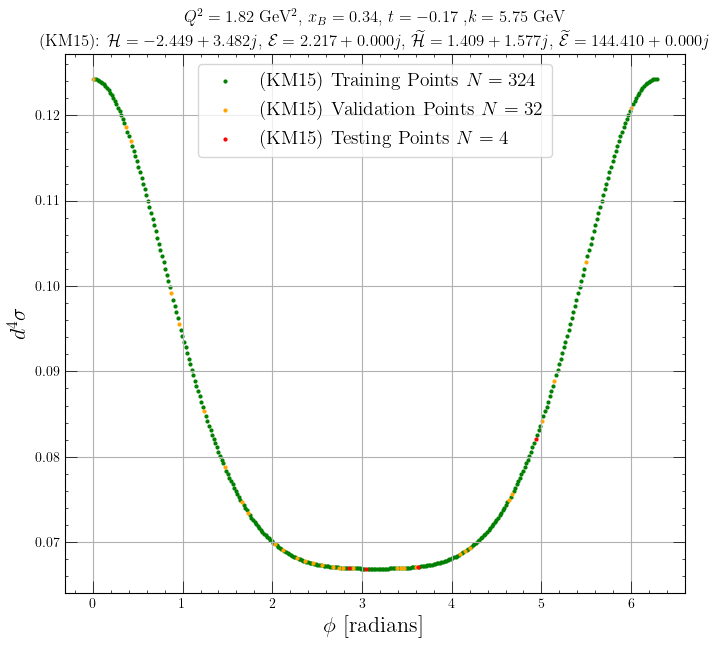

In [35]:
data_vis_figure, data_vis_axis = plt.subplots(1, 1, figsize = (8, 7))

data_vis_axis.scatter(x_training_phi_points, x_training_bkm10_xsec, color = 'green', s = 4., label = rf"(KM15) Training Points $N = {len(x_training_phi_points)}$")
data_vis_axis.scatter(x_validation_phi_points, x_validation_bkm10_xsec, color = 'orange', s = 4., label = rf"(KM15) Validation Points $N = {len(x_validation_phi_points)}$")
data_vis_axis.scatter(x_testing_phi_points, x_testing_bkm10_xsec, color = 'red', s = 4., label = rf"(KM15) Testing Points $N = {len(x_testing_phi_points)}$")

data_vis_axis.legend(fontsize = 14.)

data_vis_axis.set_xlabel(r"$\phi$ [radians]", fontsize = 16.)
data_vis_axis.set_ylabel(r"$d^{4}\sigma$", fontsize = 16.)
data_vis_axis.set_title(f"{title_string}\n(KM15): {km15_cff_string}")
# data_vis_axis.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")

data_vis_axis.grid(visible = True)

#### (3.4.3): Making the BSA Plot:

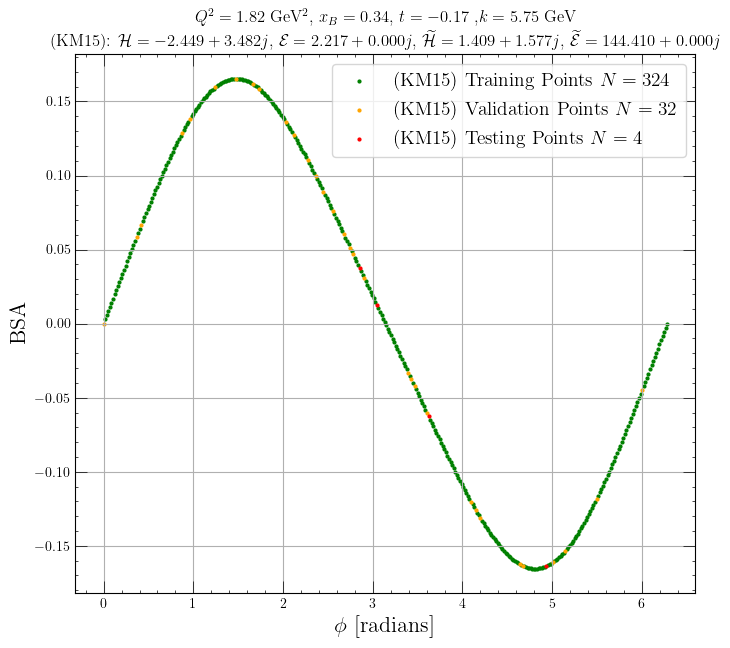

In [36]:
bsa_train_test_split_figure, bsa_train_test_split_axis = plt.subplots(1, 1, figsize = (8, 7))

bsa_train_test_split_axis.scatter(x_training_phi_points, x_training_bkm10_bsa, color = 'green', s = 4., label = rf"(KM15) Training Points $N = {len(x_training_phi_points)}$")
bsa_train_test_split_axis.scatter(x_validation_phi_points, x_validation_bkm10_bsa, color = 'orange', s = 4., label = rf"(KM15) Validation Points $N = {len(x_validation_phi_points)}$")
bsa_train_test_split_axis.scatter(x_testing_phi_points, x_testing_bkm10_bsa, color = 'red', s = 4., label = rf"(KM15) Testing Points $N = {len(x_testing_phi_points)}$")

bsa_train_test_split_axis.legend(fontsize = 14.)

bsa_train_test_split_axis.set_xlabel(r"$\phi$ [radians]", fontsize = 16.)
bsa_train_test_split_axis.set_ylabel(r"BSA", fontsize = 16.)
bsa_train_test_split_axis.set_title(f"{title_string}\n(KM15): {km15_cff_string}")
# bsa_train_test_split_axis.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")

bsa_train_test_split_axis.grid(visible = True)

## (4): DNN Model Definitions:

We need to go through all of this section in order to get TensorFlow working with the BKM10 custom computation for the cross-section and BSA.

### (4.1): Static Quantities Used in Loss Computation:

**Important**: `Q_SQUARED` ($Q^{2}$) and `_LAB_K_BEAM` ($k$) are treated as fixed the ENTIRE TIME during training.

#### (4.1.1): Statics in Loss Computation:

In [37]:
# _MASS_OF_PROTON_IN_GEV = 0.93827208816
# _ELECTRIC_FORM_FACTOR_CONSTANT = 0.710649
# _PROTON_MAGNETIC_MOMENT = 2.79284734463

_CONVERSION_FACTOR = tf.constant(.389379 * 1000000., dtype = _FLOATX)

_MASS_OF_PROTON_IN_GEV = tf.constant(0.93827208816, dtype = _FLOATX)
_QED_FINE_STRUCTURE = tf.constant(1./137.035999177, dtype = _FLOATX)
_ELECTRIC_FORM_FACTOR_CONSTANT = tf.constant(0.710649, dtype = _FLOATX)
_PROTON_MAGNETIC_MOMENT = tf.constant(2.79284734463, dtype = _FLOATX)

### (4.1.2): Important Statics (Kinematics)

- `_LAB_K_BEAM` are **here**!!
- Only fix `_Q_SQUARED` if you want to neglect QCD evolution stuff!

In [38]:
# _LAB_K_BEAM = test_dataframe["k"].iloc[0]
# _Q_SQUARED = test_dataframe["q_squared"].iloc[0]

_LAB_K_BEAM = tf.constant(test_dataframe["k"].iloc[0], dtype = _FLOATX)
# _Q_SQUARED = tf.constant(test_dataframe["q_squared"].iloc[0], dtype = _FLOATX)

#### (4.1.2.1): Check Out the Static Quantities in the Kinematics:

Why did we use this `.iloc[0]`? Because we knew that the dataset doesn't change across a single kinematic bin; effectively, the dataset depicts the CFFs as functions of $\phi$ only. We could have chosen any one of the indices of the DF as an index, and it would have pulled out the same value for `_LAB_K_BEAM` and `_Q_SQUARED`. Proof is below:

In [39]:
print(f"Is it invariant under index? {test_dataframe["q_squared"].iloc[0] == test_dataframe["q_squared"].iloc[5]}")
print(f"Is it invariant under index? {test_dataframe["k"].iloc[0] == test_dataframe["k"].iloc[10]}")

Is it invariant under index? True
Is it invariant under index? True


In [40]:
print(f"Fixed k is: {_LAB_K_BEAM}")
# print(f"Fixed Q^2 is: {_Q_SQUARED}")

# _LAB_K_BEAM = 27.6
# _Q_SQUARED = 2.0  

Fixed k is: 5.75


### (4.2): Relevant Functions in Loss Computation:

These equations below come from the HERMES paper that the DNN one took their data from. I am assuming the DNN paper also used the equations in the HERMES paper to compute the BSA and BCA.

#### (4.2.1): Kinematic Stuff:

In [41]:
def compute_fe(t):
    return tf.divide(1., tf.square(1. - tf.divide(t, _ELECTRIC_FORM_FACTOR_CONSTANT)))

def compute_fg(fe):
    return _PROTON_MAGNETIC_MOMENT * fe

def compute_f2(t, fe, fg):
    tau = tf.divide(-1. * t, 4. * tf.square(_MASS_OF_PROTON_IN_GEV))
    numerator = fg - fe
    denominator = 1. + tau
    return tf.divide(numerator, denominator)

def compute_f1(fg, f2):
    return fg - f2

def compute_epsilon(xb, q_squared):
    return tf.divide(2. * xb * _MASS_OF_PROTON_IN_GEV, tf.sqrt(q_squared))

def compute_y(k_beam, q_squared, ep):
    return tf.sqrt(q_squared) / (ep * k_beam)

def compute_skewness(xb, t, q_squared):
    return xb * (1. + (t / (2. * q_squared))) / (2. - xb + (xb * t / q_squared))

def compute_t_min(xb, q_squared, ep):
    return -1. * q_squared * ((2. * (1. - xb) * (1. - tf.sqrt(1. + ep**2))) + ep**2) / ((4. * xb * (1. - xb)) + ep**2)

def compute_t_prime(t, tmin):
    return (t-tmin)

def compute_k_tilde(xb, q_squared, t, tmin, ep):
    return tf.sqrt(tmin - t) * tf.sqrt(((1. - xb) * tf.sqrt((1. + ep**2))) + (((tmin - t) * (ep**2 + (4. * (1. - xb) * xb))) / (4. * q_squared)))

def compute_k(q_squared, y_lep, ep, k_tilde):
    return tf.sqrt(((1. - y_lep + (ep**2 * y_lep**2 / 4.)) / q_squared)) * k_tilde

def compute_k_dot_delta(q_squared, xb, t, phi_azi, ep, y_lep, k):
    return (-1.*q_squared / (2.*y_lep*(1.+ep**2))) * (1. + ((2.*k*tf.cos(tf.constant(np.pi)- phi_azi)) - ((t / q_squared)*(1.-(xb * (2. - y_lep)) + (y_lep * ep**2 / 2.))) + (y_lep * ep**2 / 2.)))

def prop_1(q_squared, kdd):
    return (1. + (2. * (kdd / q_squared)))

def prop_2(q_squared, t, kdd):
    return ((-2. * (kdd / q_squared)) + (t / q_squared))

#### (4.2.2): BH Coefficients:

In [ ]:
def bh_unp_c0(
    q_sq: float, xb: float, t: float, ep: float,
    y: float, k: float, f1: float, f2: float):
    first_line = 8. * k**2 * (((2. + 3. * ep**2) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) / (t / q_sq)) + (2. * xb**2 * (f1 + f2)**2))
    second_line_first_part = (2. + ep**2) * ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) * (1. + (t / q_sq))**2 + 4. * (1 - xb) * (1. + (xb * (t / q_sq)))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2)))
    second_line_second_part = 4. * xb**2 * (xb + (1. - xb + (ep**2 / 2.)) * (1 - (t / q_sq))**2 - xb * (1. - 2. * xb) * (t / q_sq)**2) * (f1 + f2)**2
    second_line = (2. - y)**2 * (second_line_first_part + second_line_second_part)
    third_line = 8. * (1. + ep**2) * (1. - y - (ep**2 * y**2 / 4.)) * (2. * ep**2 * (1 - (t / (4. * _MASS_OF_PROTON_IN_GEV**2))) * (f1**2 - (t * f2**2 / (4. * _MASS_OF_PROTON_IN_GEV**2))) - xb**2 * (1 - (t / q_sq))**2 * (f1 + f2)**2)
    c0_unpolarized_bh = first_line + second_line + third_line
    return c0_unpolarized_bh

def bh_unp_c1(
    q_sq: float, xb: float, t: float, ep: float,
    y: float, k: float, f1: float, f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t / (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_line_first_part = ((4. * xb**2 * _MASS_OF_PROTON_IN_GEV**2 / t) - 2. * xb - ep**2) * weighted_combination_of_form_factors
    first_line_second_part = 2. * xb**2 * (1. - (1. - 2. * xb) * (t / q_sq)) * addition_of_form_factors_squared
    c1_unpolarized_bh = 8. * k * (2. - y) * (first_line_first_part + first_line_second_part)
    return c1_unpolarized_bh

def bh_unp_c2( 
    xb: float, t: float, k: float, f1: float, f2: float) -> float:
    addition_of_form_factors_squared = (f1 + f2)**2
    weighted_combination_of_form_factors = f1**2 - ((t/ (4. * _MASS_OF_PROTON_IN_GEV**2)) * f2**2)
    first_part_of_contribution = (4. * _MASS_OF_PROTON_IN_GEV**2 / t) * weighted_combination_of_form_factors
    c2_unpolarized_bh = 8. * xb**2 * k**2 * (first_part_of_contribution + 2. * addition_of_form_factors_squared)
    return c2_unpolarized_bh


#### (4.2.3): BH Amplitude Squared:

In [ ]:
def bh_squared(lep_helicity, target_polar, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2):

    if lep_helicity == 0.0 and target_polar == 0.0:
        bh_c0 = 0.5 * (bh_unp_c0(q_sq, xb, t, ep, y, k, f1, f2) + bh_unp_c0(q_sq, xb, t, ep, y, k, f1, f2))
        bh_c1 = 0.5 * (bh_unp_c1(q_sq, xb, t, ep, y, k, f1, f2) + bh_unp_c1(q_sq, xb, t, ep, y, k, f1, f2))
        bh_c2 = 0.5 * (bh_unp_c2(xb, t, k, f1, f2) + bh_unp_c2(xb, t, k, f1, f2))
    elif lep_helicity == 1.0 and target_polar == 0.0:
        bh_c0 = bh_unp_c0(q_sq, xb, t, ep, y, k, f1, f2)
        bh_c1 = bh_unp_c1(q_sq, xb, t, ep, y, k, f1, f2)
        bh_c2 = bh_unp_c2(xb, t, k, f1, f2)
    elif lep_helicity == -1.0 and target_polar == 0.0: 
        bh_c0 = bh_unp_c0(q_sq, xb, t, ep, y, k, f1, f2)
        bh_c1 = bh_unp_c1(q_sq, xb, t, ep, y, k, f1, f2)
        bh_c2 = bh_unp_c2(xb, t, k, f1, f2)
    elif lep_helicity == 1.0 and target_polar == 1.0:
        raise NotImplementedError("[ERROR]: NO POLARIZED TARGET YET!")
    
    return ((
        bh_c0 + 
        bh_c1 * tf.cos(1.* (tf.constant(np.pi) - phi)) + 
        bh_c2 * tf.cos(2.* (tf.constant(np.pi) - phi))) / (xb * xb * y * y * (1.+ep**2)**2 * t * p1 * p2))

#### (4.2.4): DVCS Coefficients:

In [44]:
def f_eff(xi: float, cff: complex, use_ww: bool = True):
    if use_ww:
        cff_effective = 2. * cff / (1. + xi)
    else:
        cff_effective = -2. * xi * cff / (1. + xi)
    return cff_effective

def curly_c_real(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):
    
    first_line = (4.*(1.-xb)*(cff_re_h*cff_re_h_star - cff_im_h*cff_im_h_star)) + (4.*(1.-xb + 0.25*((2.*q_sq + t)*ep**2)/(q_sq + xb*t))*(cff_re_ht * cff_re_ht_star - cff_im_ht * cff_im_ht_star))
    next_line = -xb**2*(q_sq+t)**2*(cff_re_h*cff_re_e_star - cff_im_e*cff_im_h_star + cff_re_e*cff_re_h_star - cff_im_h*cff_im_e_star)/(q_sq*(q_sq+xb*t)) - (xb**2*q_sq*(cff_re_ht*cff_re_et_star - cff_im_et *cff_im_ht_star + cff_re_et*cff_re_ht_star - cff_im_ht*cff_im_et_star)/(q_sq+xb*t))
    final_line = -1.*(xb**2*(q_sq+t)**2/(q_sq*(q_sq+xb*t)) + 0.25*((2.-xb)*q_sq+xb*t)**2*t/(q_sq*_MASS_OF_PROTON_IN_GEV**2*(q_sq+xb*t)))*(cff_re_e*cff_re_e_star - cff_im_e*cff_im_e_star) -0.25*xb**2*q_sq*t*(cff_re_et*cff_re_et_star - cff_im_et*cff_im_et_star)/((q_sq+xb*t)*_MASS_OF_PROTON_IN_GEV**2)

    return ((first_line + next_line + final_line)*q_sq*(q_sq+xb*t)/((2.-xb)*q_sq+xb*t)**2)

def curly_c_imag(
    q_sq: float, xb: float, t: float, ep: float,
    cff_re_h: float, cff_re_ht: float, cff_re_e: float, cff_re_et: float,
    cff_im_h: float, cff_im_ht: float, cff_im_e: float, cff_im_et: float,
    cff_re_h_star: float, cff_re_ht_star: float, cff_re_e_star: float, cff_re_et_star: float,
    cff_im_h_star: float, cff_im_ht_star: float, cff_im_e_star: float, cff_im_et_star: float):
    
    first_line = (4.*(1.-xb)*(cff_im_h*cff_re_h_star + cff_re_h*cff_im_h_star)) + (4.*(1.-xb + 0.25*(2.*q_sq + t)*ep**2/(q_sq + xb*t))*(cff_im_ht * cff_re_ht_star + cff_re_ht * cff_im_ht_star))
    next_line = -xb**2*(q_sq+t)**2*(cff_im_h*cff_re_e_star + cff_re_e*cff_im_h_star + cff_im_e*cff_re_h_star + cff_re_h*cff_im_e_star)/(q_sq*(q_sq+xb*t)) - (xb**2*q_sq*(cff_im_ht*cff_re_et_star + cff_re_et*cff_im_ht_star + cff_im_et*cff_re_ht_star + cff_re_ht*cff_im_et_star)/(q_sq+xb*t))
    final_line = -1.*(xb**2*(q_sq+t)**2/(q_sq*(q_sq+xb*t)) + 0.25*((2.-xb)*q_sq+xb*t)**2*t/(q_sq*_MASS_OF_PROTON_IN_GEV**2*(q_sq+xb*t)))*(cff_im_e*cff_re_e_star + cff_re_e*cff_im_e_star) -0.25*xb**2*q_sq*t*(cff_im_et*cff_re_et_star + cff_re_et*cff_im_et_star)/((q_sq+xb*t)*_MASS_OF_PROTON_IN_GEV**2)

    return ((first_line + next_line + final_line)*q_sq*(q_sq+xb*t)/((2.-xb)*q_sq+xb*t)**2)

def dvcs_unp_c0(
    q_sq: float, 
    xb: float, 
    t: float,
    ep: float,
    y: float, 
    xi: float,
    k: float,
    cff_re_h: float,
    cff_re_ht: float,
    cff_re_e: float,
    cff_re_et: float,
    cff_im_h: float,
    cff_im_ht: float,
    cff_im_e: float,
    cff_im_et: float,
    use_ww: bool = True) -> float:
    
    first_term_prefactor = 2. * ( 2. - 2. * y + y**2 + (ep**2 * y**2 / 2.)) / (1. + ep**2)
    second_term_prefactor = 16. * k**2 / ((2. - xb)**2 * (1. + ep**2))
    first_term_curlyc = curly_c_real(
        q_sq, xb, t, ep,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        cff_im_h, cff_im_ht, cff_im_e, cff_im_et,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    second_term_curlyc = curly_c_real(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_e, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, -1.*cff_im_h, use_ww), f_eff(xi, -1.*cff_im_ht, use_ww), f_eff(xi, -1.*cff_im_e, use_ww), f_eff(xi, -1.*cff_im_et, use_ww))
    c0_dvcs_unpolarized_coefficient = first_term_prefactor * first_term_curlyc + second_term_prefactor * second_term_curlyc
    return c0_dvcs_unpolarized_coefficient

def dvcs_unp_c1(
    q_sq: float,
    xb: float,
    t: float,
    ep: float,
    y: float,
    xi: float,
    k: float,
    cff_re_h: float,
    cff_re_ht: float,
    cff_re_e: float,
    cff_re_et: float,
    cff_im_h: float,
    cff_im_ht: float,
    cff_im_e: float,
    cff_im_et: float,
    use_ww: bool = True) -> float:

    prefactor = 8. * k * (2. - y) / ((2. - xb) * (1. + ep**2))
    curlyC_unp_DVCS = curly_c_real(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)

def dvcs_unp_s1(
    lepton_helicity: float,
    q_sq: float,
    xb: float,
    t: float,
    ep: float,
    y: float,
    xi: float,
    k: float,
    cff_re_h: float,
    cff_re_ht: float,
    cff_re_e: float,
    cff_re_et: float,
    cff_im_h: float,
    cff_im_ht: float,
    cff_im_e: float,
    cff_im_et: float,
    use_ww: bool = True) -> float:
    prefactor = -8. * k * lepton_helicity * y * tf.sqrt(1. + ep**2) / ((2. - xb) * (1. + ep**2))
    curlyC_unp_DVCS = curly_c_imag(
        q_sq, xb, t, ep,
        f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww), f_eff(xi, cff_re_et, use_ww),
        f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww), f_eff(xi, cff_im_et, use_ww),
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et,
        -1.*cff_im_h, -1.*cff_im_ht, -1.*cff_im_e, -1.*cff_im_et)
    return (prefactor * curlyC_unp_DVCS)



#### (4.3.5): DVCS Amplitude Squared Function

In [ ]:
def dvcs_squared(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, phi,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    if target_polar == 1.0:
        raise NotImplementedError("[ERROR]: NO POLARIZED TARGET YET!")
    
    if lep_helicity == 0.0:
        dvcs_c0 = 0.5 * (
            dvcs_unp_c0(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww) +
            dvcs_unp_c0(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
        )

        dvcs_c1 = 0.5 * (
            dvcs_unp_c1(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww) +
            dvcs_unp_c1(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
        )
        dvcs_s1 = 0.5 * (
            dvcs_unp_s1(1.0, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww) +
            dvcs_unp_s1(-1.0, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
        )
    else:
        dvcs_c0 = dvcs_unp_c0(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
        dvcs_c1 = dvcs_unp_c1(q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
        dvcs_s1 = dvcs_unp_s1(lep_helicity, q_sq, xb, t, ep, y, xi, k, cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    return (
        (dvcs_c0 + 
         dvcs_c1 * tf.cos(1.* (tf.constant(np.pi) - phi)) + 
         dvcs_s1 * tf.sin(1.* (tf.constant(np.pi) - phi))) / (y * y * q_sq))

#### (4.3.6): Interference Coefficients:

In [ ]:
def i_c_unp_pp_0(
    q_sq: float,xb: float,t: float,ep: float,y: float,k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    two_minus_xb = 2. - xb
    two_minus_y = 2. - y
    first_term_in_brackets = k_tilde**2 * two_minus_y**2 / (q_sq * root_one_plus_epsilon_squared)
    second_term_in_brackets_first_part = t_over_Q_squared * two_minus_xb * (1. - y - (ep**2 * y**2 / 4.))
    second_term_in_brackets_second_part_numerator = 2. * xb * t_over_Q_squared * (two_minus_xb + 0.5 * (root_one_plus_epsilon_squared - 1.) + 0.5 * ep**2 / xb) + ep**2
    second_term_in_brackets_second_part =  1. + second_term_in_brackets_second_part_numerator / (two_minus_xb * one_plus_root_epsilon_stuff)
    prefactor = -4. * two_minus_y * one_plus_root_epsilon_stuff / tf.pow(root_one_plus_epsilon_squared, 4)
    c_0_plus_plus_unp = prefactor * (first_term_in_brackets + second_term_in_brackets_first_part * second_term_in_brackets_second_part)
    return c_0_plus_plus_unp

def i_c_unp_v_pp_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_term_in_brackets = (2. - y)**2 * k_tilde**2 / (root_one_plus_epsilon_squared * q_sq)
    second_term_first_multiplicative_term = 1. - y - (ep**2 * y**2 / 4.)
    second_term_second_multiplicative_term = one_plus_root_epsilon_stuff / 2.
    second_term_third_multiplicative_term = 1. + t_over_Q_squared
    second_term_fourth_multiplicative_term = 1. + (root_one_plus_epsilon_squared - 1. + (2. * xb)) * t_over_Q_squared / one_plus_root_epsilon_stuff
    second_term_in_brackets = second_term_first_multiplicative_term * second_term_second_multiplicative_term * second_term_third_multiplicative_term * second_term_fourth_multiplicative_term
    coefficient_prefactor = 8. * (2. - y) * xb * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_0_plus_plus_V_unp = coefficient_prefactor * (first_term_in_brackets + second_term_in_brackets)
    return c_0_plus_plus_V_unp

def i_c_unp_a_pp_0(
    q_sq: float,xb: float,t: float,ep: float,y: float,k_tilde: float) -> float:
    root_one_plus_epsilon_squared = tf.sqrt(1. + ep**2)
    t_over_Q_squared = t / q_sq
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    two_minus_y = 2. - y
    ktilde_over_Q_squared = k_tilde**2 / q_sq
    curly_bracket_first_term = two_minus_y**2 * ktilde_over_Q_squared * (one_plus_root_epsilon_stuff - 2. * xb) / (2. * root_one_plus_epsilon_squared)
    deepest_parentheses_term = (xb * (2. + one_plus_root_epsilon_stuff - 2. * xb) / one_plus_root_epsilon_stuff + (one_plus_root_epsilon_stuff - 2.)) * t_over_Q_squared
    square_bracket_term = one_plus_root_epsilon_stuff * (one_plus_root_epsilon_stuff - xb + deepest_parentheses_term) / 2. - (2. * ktilde_over_Q_squared)
    curly_bracket_second_term = (1. - y - ep**2 * y**2 / 4.) * square_bracket_term
    coefficient_prefactor = 8. * two_minus_y * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_0_plus_plus_A_unp = coefficient_prefactor * (curly_bracket_first_term + curly_bracket_second_term)
    return c_0_plus_plus_A_unp

def i_c_unp_0p_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k: float):
    bracket_quantity = ep**2 + t * (2. - 6.* xb - ep**2) / (3. * q_sq)
    prefactor = 12. * tf.sqrt(2.) * k * (2. - y) * tf.sqrt(1. - y - (ep**2 * y**2 / 4)) / tf.pow(1. + ep**2, 2.5)
    c_0_zero_plus_unp = prefactor * bracket_quantity
    return c_0_zero_plus_unp

def i_c_unp_v_0p_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k: float):
    t_over_Q_squared = t / q_sq
    main_part = xb * t_over_Q_squared * (1. - (1. - 2. * xb) * t_over_Q_squared)
    prefactor = 24. * tf.sqrt(2.) * k * (2. - y) * tf.sqrt(1. - y - (y**2 * ep**2 / 4.)) / (1. + ep**2)**2.5
    c_0_zero_plus_V_unp = prefactor * main_part
    return c_0_zero_plus_V_unp

def i_c_unp_a_0p_0(
    q_sq: float, xb: float, t: float,ep: float,y: float, k: float):
    t_over_Q_squared = t / q_sq
    fancy_xb_epsilon_term = 8. - 6. * xb + 5. * ep**2
    brackets_term = 1. - t_over_Q_squared * (2. - 12. * xb * (1. - xb) - ep**2) / fancy_xb_epsilon_term
    prefactor = 4. * tf.sqrt(2.) * k * (2. - y) * tf.sqrt(1. - y - (y**2 * ep**2 / 4.)) / tf.pow(1. + ep**2, 2.5)
    c_0_zero_plus_A_unp = prefactor * t_over_Q_squared * fancy_xb_epsilon_term * brackets_term
    return c_0_zero_plus_A_unp

In [47]:
def i_c_unp_pp_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    one_plus_root_epsilon_stuff = 1. + root_one_plus_epsilon_squared
    first_bracket_first_term = (1. + (1. - x_Bjorken) * (root_one_plus_epsilon_squared - 1.) / (2. * x_Bjorken) + epsilon**2 / (4. * x_Bjorken)) * x_Bjorken * t_over_Q_squared
    first_bracket_term = first_bracket_first_term - 3. * epsilon**2 / 4.
    second_bracket_term = 1. - (1. - 3. * x_Bjorken) * t_over_Q_squared + (1. - root_one_plus_epsilon_squared + 3. * epsilon**2) * x_Bjorken * t_over_Q_squared / (one_plus_root_epsilon_stuff - epsilon**2)
    fancy_y_coefficient = 2. - 2. * lepton_energy_fraction_y + lepton_energy_fraction_y**2 + epsilon**2 * lepton_energy_fraction_y**2 / 2.
    second_term = -4. * shorthand_k * fancy_y_coefficient * (one_plus_root_epsilon_stuff - epsilon**2) * second_bracket_term / root_one_plus_epsilon_squared**5
    first_term = -16. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * first_bracket_term / root_one_plus_epsilon_squared**5
    c_1_plus_plus_unp = first_term + second_term
    return c_1_plus_plus_unp

def i_c_unp_v_pp_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    first_bracket_term = (2. - lepton_energy_fraction_y)**2 * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)
    second_bracket_term_first_part = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    second_bracket_term_second_part = 0.5 * (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * t_prime / squared_Q_momentum_transfer
    coefficient_prefactor = 16. * shorthand_k * x_Bjorken * t_over_Q_squared / tf.pow(root_one_plus_epsilon_squared, 5)
    c_1_plus_plus_V_unp = coefficient_prefactor * (first_bracket_term + second_bracket_term_first_part * second_bracket_term_second_part)
    return c_1_plus_plus_V_unp

def i_c_unp_a_pp_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    one_minus_2xb = 1. - 2. * x_Bjorken
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    first_bracket_term_second_part = 1. - one_minus_2xb * t_over_Q_squared + (4. * x_Bjorken * one_minus_xb + epsilon**2) * t_prime_over_Q_squared / (4. * root_one_plus_epsilon_squared)
    second_bracket_term = 1. - 0.5 * x_Bjorken + 0.25 * (one_minus_2xb + root_one_plus_epsilon_squared) * (1. - t_over_Q_squared) + (4. * x_Bjorken * one_minus_xb + epsilon**2) * t_prime_over_Q_squared / (2. * root_one_plus_epsilon_squared)
    prefactor = -16. * shorthand_k * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_1_plus_plus_A_unp = prefactor * (fancy_y_stuff * first_bracket_term_second_part - (2. - lepton_energy_fraction_y)**2 * second_bracket_term)
    return c_1_plus_plus_A_unp

def i_c_unp_0p_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    first_bracket_term = (2. - lepton_energy_fraction_y)**2 * t_prime_over_Q_squared * (one_minus_xb + (one_minus_xb * x_Bjorken + (epsilon**2 / 4.)) * t_prime_over_Q_squared / root_one_plus_epsilon_squared)
    second_bracket_term = y_quantity * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared) * (epsilon**2 - 2. * (1. + (epsilon**2 / (2. * x_Bjorken))) * x_Bjorken * t_over_Q_squared) / root_one_plus_epsilon_squared
    prefactor = 8. * tf.sqrt(2. * y_quantity) / root_one_plus_epsilon_squared**4
    c_1_zero_plus_unp = prefactor * (first_bracket_term + second_bracket_term)
    return c_1_zero_plus_unp

def i_c_unp_v_0p_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    k_tilde: float):
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    major_part = (2 - lepton_energy_fraction_y)**2 * k_tilde**2 / squared_Q_momentum_transfer + (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)**2 * y_quantity
    prefactor = 16. * tf.sqrt(2. * y_quantity) * x_Bjorken * t_over_Q_squared / (1. + epsilon**2)**2.5
    c_1_zero_plus_V_unp = prefactor * major_part
    return c_1_zero_plus_V_unp

def i_c_unp_a_0p_1(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    one_minus_2xb = 1. - 2. * x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    second_term_first_part = (1. - one_minus_2xb * t_over_Q_squared) * y_quantity
    second_term_second_part = 4. - 2. * x_Bjorken + 3. * epsilon**2 + t_over_Q_squared * (4. * x_Bjorken * (1. - x_Bjorken) + epsilon**2)
    first_term = k_tilde**2 * one_minus_2xb * (2. - lepton_energy_fraction_y)**2 / squared_Q_momentum_transfer
    prefactor = 8. * tf.sqrt(2. * y_quantity) * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_1_zero_plus_unp_A = prefactor * (first_term + second_term_first_part * second_term_second_part)
    return c_1_zero_plus_unp_A

In [48]:
def i_s_unp_pp_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    bracket_term = 1. + ((1. - x_Bjorken + 0.5 * (root_one_plus_epsilon_squared - 1.)) / root_one_plus_epsilon_squared**2) * tPrime_over_Q_squared
    prefactor = 8. * lepton_helicity * shorthand_k * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) / root_one_plus_epsilon_squared**2
    s_1_plus_plus_unp = prefactor * bracket_term
    return s_1_plus_plus_unp

def i_s_unp_v_pp_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    bracket_term = root_one_plus_epsilon_squared - 1. + (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * t_over_Q_squared
    prefactor = -8. * lepton_helicity * shorthand_k * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    s_1_plus_plus_unp_V = prefactor * bracket_term
    return s_1_plus_plus_unp_V

def i_s_unp_a_pp_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_2xb = 1. - 2. * x_Bjorken
    bracket_term = 1. - one_minus_2xb * (one_minus_2xb + root_one_plus_epsilon_squared) * tPrime_over_Q_squared / (2. * root_one_plus_epsilon_squared)
    prefactor = 8. * lepton_helicity * shorthand_k * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * t_over_Q_squared / root_one_plus_epsilon_squared**2
    s_1_plus_plus_unp_A = prefactor * bracket_term
    return s_1_plus_plus_unp_A

def i_s_unp_0p_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    epsilon: float,
    lepton_energy_fraction_y: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = (1. + epsilon**2)**2
    y_quantity = tf.sqrt(1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.))
    s_1_zero_plus_unp = 8. * tf.sqrt(2.) * lepton_helicity * (2. - lepton_energy_fraction_y) * lepton_energy_fraction_y * y_quantity * k_tilde**2 / (root_one_plus_epsilon_squared * squared_Q_momentum_transfer)
    return s_1_zero_plus_unp

def i_s_unp_v_0p_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float):
    one_plus_epsilon_squared_squared = (1. + epsilon**2)**2
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    bracket_term = 4. * (1. - 2. * x_Bjorken) * t_over_Q_squared * (1. + x_Bjorken * t_over_Q_squared) + epsilon**2 * (1. + t_over_Q_squared)**2
    prefactor = 4. * tf.sqrt(2. * fancy_y_stuff) * lepton_helicity * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * x_Bjorken * t_over_Q_squared / one_plus_epsilon_squared_squared
    s_1_zero_plus_unp_V = prefactor * bracket_term
    return s_1_zero_plus_unp_V

def i_s_unp_a_0p_1(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    one_plus_epsilon_squared_squared = (1. + epsilon**2)**2
    fancy_y_stuff = tf.sqrt(1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    prefactor = -8. * tf.sqrt(2.) * lepton_helicity * lepton_energy_fraction_y * (2. - lepton_energy_fraction_y) * (1. - 2. * x_Bjorken) / one_plus_epsilon_squared_squared
    s_1_zero_plus_unp_A = prefactor * fancy_y_stuff * squared_hadronic_momentum_transfer_t * shorthand_k**2 / squared_Q_momentum_transfer
    return s_1_zero_plus_unp_A

In [49]:
def i_c_unp_pp_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    first_bracket_term = 2. * epsilon**2 * k_tilde**2 / (root_one_plus_epsilon_squared * (1. + root_one_plus_epsilon_squared) * squared_Q_momentum_transfer)
    second_bracket_term = x_Bjorken * t_prime * t_over_Q_squared * (1. - x_Bjorken - 0.5 * (root_one_plus_epsilon_squared - 1.) + 0.5 * epsilon**2 / x_Bjorken) / squared_Q_momentum_transfer
    prefactor = 8. * (2. - lepton_energy_fraction_y) * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) / root_one_plus_epsilon_squared**4
    c_2_plus_plus_unp = prefactor * (first_bracket_term + second_bracket_term)
    return c_2_plus_plus_unp

def i_c_unp_v_pp_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    major_term = (4. * k_tilde**2 / (root_one_plus_epsilon_squared * squared_Q_momentum_transfer)) + 0.5 * (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * (1. + t_over_Q_squared) * t_prime_over_Q_squared
    prefactor = 8. * (2. - lepton_energy_fraction_y) * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_plus_plus_V_unp = prefactor * major_term
    return c_2_plus_plus_V_unp

def i_c_unp_a_pp_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    k_tilde: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    first_bracket_term = 4. * (1. - 2. * x_Bjorken) * k_tilde**2 / (root_one_plus_epsilon_squared * squared_Q_momentum_transfer)
    second_bracket_term = (3.  - root_one_plus_epsilon_squared - 2. * x_Bjorken + epsilon**2 / x_Bjorken ) * x_Bjorken * t_prime_over_Q_squared
    prefactor = 4. * (2. - lepton_energy_fraction_y) * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_plus_plus_A_unp = prefactor * (first_bracket_term - second_bracket_term)
    return c_2_plus_plus_A_unp

def i_c_unp_0p_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    epsilon_squared_over_2 = epsilon**2 / 2.
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    bracket_term = 1. + ((1. + epsilon_squared_over_2 / x_Bjorken) / (1. + epsilon_squared_over_2)) * x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    prefactor = -8. * tf.sqrt(2. * y_quantity) * shorthand_k * (2. - lepton_energy_fraction_y) / root_one_plus_epsilon_squared**5
    c_2_zero_plus_unp = prefactor * (1. + epsilon_squared_over_2) * bracket_term
    return c_2_zero_plus_unp

def i_c_unp_v_0p_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    y_quantity = tf.sqrt(1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.))
    prefactor = 8. * tf.sqrt(2.) * y_quantity * shorthand_k * (2. - lepton_energy_fraction_y) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_2_zero_plus_unp_V = prefactor * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)
    return c_2_zero_plus_unp_V

def i_c_unp_a_0p_2(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    t_prime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    bracket_term = one_minus_xb + 0.5 * t_prime_over_Q_squared * (4. * x_Bjorken * one_minus_xb + epsilon**2) / root_one_plus_epsilon_squared
    prefactor = 8. * tf.sqrt(2. * y_quantity) * shorthand_k * (2. - lepton_energy_fraction_y) * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_zero_plus_unp_A = prefactor * bracket_term
    return c_2_zero_plus_unp_A

In [50]:
def i_s_unp_pp_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    epsilon: float,
    lepton_energy_fraction_y: float,
    t_prime: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    first_bracket_term = (epsilon**2 - x_Bjorken * (root_one_plus_epsilon_squared - 1.)) / (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken)
    second_bracket_term = (2. * x_Bjorken + epsilon**2) * tPrime_over_Q_squared / (2. * root_one_plus_epsilon_squared)
    prefactor = -4. * lepton_helicity * fancy_y_stuff * lepton_energy_fraction_y * (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * tPrime_over_Q_squared / root_one_plus_epsilon_squared**3
    s_2_plus_plus_unp = prefactor * (first_bracket_term - second_bracket_term)
    return s_2_plus_plus_unp

def i_s_unp_v_pp_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    one_minus_2xb = 1. - 2. * x_Bjorken
    bracket_term = root_one_plus_epsilon_squared - 1. + (one_minus_2xb + root_one_plus_epsilon_squared) * t_over_Q_squared
    parentheses_term = 1. - one_minus_2xb * t_over_Q_squared
    prefactor = -4. * lepton_helicity * fancy_y_stuff * lepton_energy_fraction_y * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    s_2_plus_plus_unp_V = prefactor * parentheses_term * bracket_term
    return s_2_plus_plus_unp_V

def i_s_unp_a_pp_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    tPrime_over_Q_squared = t_prime / squared_Q_momentum_transfer
    fancy_y_stuff = 1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.
    last_term = 1. + (4. * (1. - x_Bjorken) * x_Bjorken + epsilon**2) * t_over_Q_squared / (4. - 2. * x_Bjorken + 3. * epsilon**2)
    middle_term = 1. + root_one_plus_epsilon_squared - 2. * x_Bjorken
    prefactor = -8. * lepton_helicity * fancy_y_stuff * lepton_energy_fraction_y * t_over_Q_squared * tPrime_over_Q_squared / root_one_plus_epsilon_squared**4
    s_2_plus_plus_unp_A = prefactor * middle_term * last_term
    return s_2_plus_plus_unp_A

def i_s_unp_0p_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    epsilon_squared_over_2 = epsilon**2 / 2.
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    bracket_term = 1. + ((1. + epsilon_squared_over_2 / x_Bjorken) / (1. + epsilon_squared_over_2)) * x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    prefactor = 8. * lepton_helicity * tf.sqrt(2. * y_quantity) * shorthand_k * lepton_energy_fraction_y / root_one_plus_epsilon_squared**4
    s_2_zero_plus_unp = prefactor * (1. + epsilon_squared_over_2) * bracket_term
    return s_2_zero_plus_unp

def i_s_unp_v_0p_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    y_quantity = tf.sqrt(1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.))
    prefactor = -8. * tf.sqrt(2.) * lepton_helicity * y_quantity * shorthand_k * lepton_energy_fraction_y * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**4
    s_2_zero_plus_unp_V = prefactor * (1. - (1. - 2. * x_Bjorken) * t_over_Q_squared)
    return s_2_zero_plus_unp_V

def i_s_unp_a_0p_2(
    lepton_helicity: float,
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    one_minus_xb = 1. - x_Bjorken
    y_quantity = 1. - lepton_energy_fraction_y - (epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    main_term = 4. * one_minus_xb + 2. * epsilon**2 + 4. * t_over_Q_squared * (4. * x_Bjorken * one_minus_xb + epsilon**2)
    prefactor = -2. * tf.sqrt(2. * y_quantity) * lepton_helicity * shorthand_k * lepton_energy_fraction_y * t_over_Q_squared / root_one_plus_epsilon_squared**4
    c_2_zero_plus_unp_A = prefactor * main_term
    return c_2_zero_plus_unp_A

In [51]:
def i_c_unp_pp_3(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float,
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    major_term = (1. - x_Bjorken) * t_over_Q_squared + 0.5 * (root_one_plus_epsilon_squared - 1.) * (1. + t_over_Q_squared)
    intermediate_term = (root_one_plus_epsilon_squared - 1.) / root_one_plus_epsilon_squared**5
    prefactor = -8. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.)
    c_3_plus_plus_unp = prefactor * intermediate_term * major_term
    return c_3_plus_plus_unp

def i_c_unp_v_pp_3(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    shorthand_k: float):
    root_one_plus_epsilon_squared = tf.sqrt(1. + epsilon**2)
    t_over_Q_squared = squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer
    major_term = root_one_plus_epsilon_squared - 1. + (1. + root_one_plus_epsilon_squared - 2. * x_Bjorken) * t_over_Q_squared
    prefactor = -8. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) * x_Bjorken * t_over_Q_squared / root_one_plus_epsilon_squared**5
    c_3_plus_plus_V_unp = prefactor * major_term
    return c_3_plus_plus_V_unp

def i_c_unp_a_pp_3(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float, 
    squared_hadronic_momentum_transfer_t: float,
    epsilon: float,
    lepton_energy_fraction_y: float, 
    t_prime: float,
    shorthand_k: float):
    main_term = squared_hadronic_momentum_transfer_t * t_prime * (x_Bjorken * (1. - x_Bjorken) + epsilon**2 / 4.) / squared_Q_momentum_transfer**2
    prefactor = 16. * shorthand_k * (1. - lepton_energy_fraction_y - epsilon**2 * lepton_energy_fraction_y**2 / 4.) / tf.pow(1. + epsilon**2, 2.5)
    c_3_plus_plus_A_unp = prefactor * main_term
    return c_3_plus_plus_A_unp

In [52]:
def i_curly_c_unp(
    squared_Q_momentum_transfer: float,
    x_Bjorken: float,
    squared_hadronic_momentum_transfer_t: float,
    Dirac_form_factor_F1: float,
    Pauli_form_factor_F2: float,
    cff_h: float,
    cff_h_tilde: float,
    cff_e: float) -> float:
    weighted_cffs = (Dirac_form_factor_F1 * cff_h) - (squared_hadronic_momentum_transfer_t * Pauli_form_factor_F2 * cff_e / (4. * _MASS_OF_PROTON_IN_GEV**2))
    second_term = x_Bjorken * (Dirac_form_factor_F1 + Pauli_form_factor_F2) * cff_h_tilde / (2. - x_Bjorken + (x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer))
    curly_C_unpolarized_interference = weighted_cffs + second_term
    return curly_C_unpolarized_interference

def i_curly_c_v_unp(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float,
    squared_hadronic_momentum_transfer_t: float,
    Dirac_form_factor_F1: float,
    Pauli_form_factor_F2: float,
    cff_h: float,
    cff_e: float) -> float:
    cff_term = cff_h + cff_e
    second_term = x_Bjorken * (Dirac_form_factor_F1 + Pauli_form_factor_F2) / (2. - x_Bjorken + (x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer))
    curly_C_unpolarized_interference_V = cff_term * second_term
    return curly_C_unpolarized_interference_V

def i_curly_c_a_unp(
    squared_Q_momentum_transfer: float, 
    x_Bjorken: float,
    squared_hadronic_momentum_transfer_t: float,
    Dirac_form_factor_F1: float,
    Pauli_form_factor_F2: float,
    cff_h: float) -> float:
    xb_modulation = x_Bjorken * (Dirac_form_factor_F1 + Pauli_form_factor_F2) / (2. - x_Bjorken + (x_Bjorken * squared_hadronic_momentum_transfer_t / squared_Q_momentum_transfer))
    curly_C_unpolarized_interference_A = cff_h * xb_modulation
    return curly_C_unpolarized_interference_A

In [53]:
def i_unp_c0(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_0 = i_c_unp_pp_0(q_sq, xb, t, ep, y, ktilde)
    i_c_pp_v_0 = i_c_unp_v_pp_0(q_sq, xb, t, ep, y, ktilde)
    i_c_pp_a_0 = i_c_unp_a_pp_0(q_sq, xb, t, ep, y, ktilde)

    i_c_0p_0 = i_c_unp_0p_0(q_sq, xb, t, ep, y, k)
    i_c_0p_v_0 = i_c_unp_v_0p_0(q_sq, xb, t, ep, y, k)
    i_c_0p_a_0 = i_c_unp_a_0p_0(q_sq, xb, t, ep, y, k)

    return (i_c_pp_0*i_curly_c + i_c_pp_v_0*i_curly_c_v + i_c_pp_a_0*i_curly_c_a + i_c_0p_0*i_curly_c_eff + i_c_0p_v_0*i_curly_c_eff_v + i_c_0p_a_0*i_curly_c_eff_a)

def i_unp_c1(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_1 = i_c_unp_pp_1(q_sq, xb, t, ep, y, k)
    i_c_pp_v_1 = i_c_unp_v_pp_1(q_sq, xb, t, ep, y, tprime, k)
    i_c_pp_a_1 = i_c_unp_a_pp_1(q_sq, xb, t, ep, y, tprime, k)

    i_c_0p_1 = i_c_unp_0p_1(q_sq, xb, t, ep, y, tprime)
    i_c_0p_v_1 = i_c_unp_v_0p_1(q_sq, xb, t, ep, y, ktilde)
    i_c_0p_a_1 = i_c_unp_a_0p_1(q_sq, xb, t, ep, y, ktilde)

    return (i_c_pp_1*i_curly_c + i_c_pp_v_1*i_curly_c_v + i_c_pp_a_1*i_curly_c_a + i_c_0p_1*i_curly_c_eff + i_c_0p_v_1*i_curly_c_eff_v + i_c_0p_a_1*i_curly_c_eff_a)

def i_unp_c2(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_2 = i_c_unp_pp_2(q_sq, xb, t, ep, y, tprime, ktilde)
    i_c_pp_v_2 = i_c_unp_v_pp_2(q_sq, xb, t, ep, y, tprime, ktilde)
    i_c_pp_a_2 = i_c_unp_a_pp_2(q_sq, xb, t, ep, y, tprime, ktilde)

    i_c_0p_2 = i_c_unp_0p_2(q_sq, xb, t, ep, y, k)
    i_c_0p_v_2 = i_c_unp_v_0p_2(q_sq, xb, t, ep, y, k)
    i_c_0p_a_2 = i_c_unp_a_0p_2(q_sq, xb, t, ep, y, tprime, k)

    return (i_c_pp_2*i_curly_c + i_c_pp_v_2*i_curly_c_v + i_c_pp_a_2*i_curly_c_a + i_c_0p_2*i_curly_c_eff + i_c_0p_v_2*i_curly_c_eff_v + i_c_0p_a_2*i_curly_c_eff_a)

def i_unp_c3(
    q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_re_h: float, cff_re_ht: float, cff_re_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_ht, cff_re_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_re_h, cff_re_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_re_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_ht, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_h, use_ww), f_eff(xi, cff_re_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_re_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_c_pp_3 = i_c_unp_pp_3(q_sq, xb, t, ep, y, k)
    i_c_pp_v_3 = i_c_unp_v_pp_3(q_sq, xb, t, ep, y, k)
    i_c_pp_a_3 = i_c_unp_a_pp_3(q_sq, xb, t, ep, y, tprime, k)

    i_c_0p_3 = 0.
    i_c_0p_v_3 = 0.
    i_c_0p_a_3 = 0.

    return (i_c_pp_3*i_curly_c + i_c_pp_v_3*i_curly_c_v + i_c_pp_a_3*i_curly_c_a + i_c_0p_3*i_curly_c_eff + i_c_0p_v_3*i_curly_c_eff_v + i_c_0p_a_3*i_curly_c_eff_a)

def i_unp_s1(
    lepton_helicity: float, q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_im_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_s_pp_1 = i_s_unp_pp_1(lepton_helicity, q_sq, xb, ep, y, tprime, k)
    i_s_pp_v_1 = i_s_unp_v_pp_1(lepton_helicity, q_sq, xb, t, ep, y, k)
    i_s_pp_a_1 = i_s_unp_a_pp_1(lepton_helicity, q_sq, xb, t, ep, y, tprime, k)

    i_s_0p_1 = i_s_unp_0p_1(lepton_helicity, q_sq, ep, y, ktilde)
    i_s_0p_v_1 = i_s_unp_v_0p_1(lepton_helicity, q_sq, xb, t, ep, y)
    i_s_0p_a_1 = i_s_unp_a_0p_1(lepton_helicity, q_sq, xb, t, ep, y, k)

    return (i_s_pp_1*i_curly_c + i_s_pp_v_1*i_curly_c_v + i_s_pp_a_1*i_curly_c_a + i_s_0p_1*i_curly_c_eff + i_s_0p_v_1*i_curly_c_eff_v + i_s_0p_a_1*i_curly_c_eff_a)

def i_unp_s2(
    lepton_helicity: float, q_sq: float, xb: float, t: float, ep: float, y: float, xi: float, k: float, tprime: float,
    f1: float, f2: float, ktilde: float, cff_im_h: float, cff_im_ht: float, cff_im_e: float, use_ww: bool = True):

    i_curly_c = i_curly_c_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_ht, cff_im_e)
    i_curly_c_v = i_curly_c_v_unp(q_sq, xb, t, f1, f2, cff_im_h, cff_im_e)
    i_curly_c_a = i_curly_c_a_unp(q_sq, xb, t, f1, f2, cff_im_ht)

    i_curly_c_eff = ktilde * tf.sqrt(2.) * i_curly_c_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_ht, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_v = ktilde * tf.sqrt(2.) * i_curly_c_v_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_h, use_ww), f_eff(xi, cff_im_e, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))
    i_curly_c_eff_a = ktilde * tf.sqrt(2.) * i_curly_c_a_unp(q_sq, xb, t, f1, f2, f_eff(xi, cff_im_ht, use_ww)) / ((2. - xb) * tf.sqrt(q_sq))

    i_s_pp_2 = i_s_unp_pp_2(lepton_helicity, q_sq, xb, ep, y, tprime)
    i_s_pp_v_2 = i_s_unp_v_pp_2(lepton_helicity, q_sq, xb, t, ep, y)
    i_s_pp_a_2 = i_s_unp_a_pp_2(lepton_helicity, q_sq, xb, t, ep, y, tprime)

    i_s_0p_2 = i_s_unp_0p_2(lepton_helicity, q_sq, xb, t, ep, y, k)
    i_s_0p_v_2 = i_s_unp_v_0p_2(lepton_helicity, q_sq, xb, t, ep, y, k)
    i_s_0p_a_2 = i_s_unp_a_0p_2(lepton_helicity, q_sq, xb, t, ep, y, k)

    return (i_s_pp_2*i_curly_c + i_s_pp_v_2*i_curly_c_v + i_s_pp_a_2*i_curly_c_a + i_s_0p_2*i_curly_c_eff + i_s_0p_v_2*i_curly_c_eff_v + i_s_0p_a_2*i_curly_c_eff_a)


#### (4.3.7): Interference Amplitude Function

In [54]:
def interference_amplitude(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_im_h, cff_im_ht, cff_im_e, use_ww: bool = True):

    if target_polar == 1.0:
        # [TODO]: Code polarized target coefficients. @Woofmagic
        raise NotImplementedError("NO POLARIZED TARGET YET!")
    
    if lep_helicity == 0.0:
        i_c0 = 0.5 * (
            i_unp_c0(q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww) +
            i_unp_c0(q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
        )

        i_c1 = 0.5 * (
            i_unp_c1(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww) +
            i_unp_c1(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
        )

        i_c2 = 0.5 * (
            i_unp_c2(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww) +
            i_unp_c2(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
        )

        i_c3 = 0.5 * (
            i_unp_c3(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww) +
            i_unp_c3(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
        )

        i_s1 = 0.5 * (
            i_unp_s1(1.0, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww) + 
            i_unp_s1(-1.0, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww)
        )

        i_s2 = 0.5 * (
            i_unp_s2(1.0, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww) +
            i_unp_s2(-1.0, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww)
        )
    else:
        i_c0 = i_unp_c0(q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
        i_c1 = i_unp_c1(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
        i_c2 = i_unp_c2(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)
        i_c3 = i_unp_c3(q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_re_h, cff_re_ht, cff_re_e, use_ww)

        i_s1 = i_unp_s1(lep_helicity, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww)
        i_s2 = i_unp_s2(lep_helicity, q_sq, xb, t, ep, y, xi, k, tprime, f1, f2, ktilde, cff_im_h, cff_im_ht, cff_im_e, use_ww)

    return ((i_c0 + 
            i_c1 * tf.cos(1. * (tf.constant(np.pi) - phi)) + 
            i_c2 * tf.cos(2. * (tf.constant(np.pi) - phi)) + 
            i_c3 * tf.cos(3. * (tf.constant(np.pi) - phi)) + 
            i_s1 * tf.sin(1. * (tf.constant(np.pi) - phi)) + 
            i_s2 * tf.sin(2. * (tf.constant(np.pi) - phi)))/(xb * y * y * y * t * p1 * p2))
    

#### (4.3.8): Total Cross-Section Function:

In [55]:
def bkm10_cross_section(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    if target_polar == 1.0:
        # [TODO]: Code polarized target coefficients. @Woofmagic
        raise NotImplementedError("NO POLARIZED TARGET YET!")
    
    bh_km15_plus_beam = bh_squared(
        +1.0, target_polar, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)

    bh_km15_minus_beam = bh_squared(
        -1.0, target_polar, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)

    dvcs_km15_plus_beam = dvcs_squared(
        +1.0, target_polar,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    
    dvcs_km15_minus_beam = dvcs_squared(
        -1.0, target_polar,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    interference_km15_plus_beam = interference_amplitude(
        +1.0, target_polar,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_im_h, cff_im_ht, cff_im_e, use_ww)
    
    interference_km15_minus_beam = interference_amplitude(
        -1.0, target_polar,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_im_h, cff_im_ht, cff_im_e, use_ww)
    
    tf_cross_section_km15 = 0.0
    
    if lep_helicity == 0.0:
        tf_cross_section_km15 = 0.5 * (
            _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*(
                bh_km15_plus_beam + bh_km15_minus_beam +
                dvcs_km15_plus_beam + dvcs_km15_minus_beam +
                interference_km15_plus_beam + interference_km15_minus_beam) / (16. * tf.square(tf.constant(np.pi)) * q_sq * tf.sqrt(1. + ep**2)))
        
    elif lep_helicity == 1.0:
        tf_cross_section_km15 = (
            _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*(
                bh_km15_plus_beam + 0.0 +
                dvcs_km15_plus_beam + 0.0 +
                interference_km15_plus_beam + 0.0) / (16. * tf.square(tf.constant(np.pi)) * q_sq * tf.sqrt(1. + ep**2)))
        
    elif lep_helicity == -1.0:
        tf_cross_section_km15 = (
            _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*(
                0.0 + bh_km15_minus_beam +
                0.0 + dvcs_km15_minus_beam +
                0.0 + interference_km15_minus_beam) / (16. * tf.square(tf.constant(np.pi)) * q_sq * tf.sqrt(1. + ep**2)))
        
    return tf_cross_section_km15

#### (4.3.9): Total BSA Function:

In [56]:
def bkm10_bsa(
    lep_helicity, target_polar, q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
    cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww: bool = True):

    if target_polar == 1.0:
        # [TODO]: Code polarized target coefficients. @Woofmagic
        raise NotImplementedError("NO POLARIZED TARGET YET!")
    
    bh_km15_plus_beam = bh_squared(
        +1.0, target_polar, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)

    bh_km15_minus_beam = bh_squared(
        -1.0, target_polar, q_sq, xb, t, ep, y, k, f1, f2, phi, p1, p2)

    dvcs_km15_plus_beam = dvcs_squared(
        +1.0, target_polar,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)
    
    dvcs_km15_minus_beam = dvcs_squared(
        -1.0, target_polar,
        q_sq, xb, t, ep, y, xi, k, phi,
        cff_re_h, cff_re_ht, cff_re_e, cff_re_et, cff_im_h, cff_im_ht, cff_im_e, cff_im_et, use_ww)

    interference_km15_plus_beam = interference_amplitude(
        +1.0, target_polar,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_im_h, cff_im_ht, cff_im_e, use_ww)
    
    interference_km15_minus_beam = interference_amplitude(
        -1.0, target_polar,
        q_sq, xb, t, ep, y, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
        cff_re_h, cff_re_ht, cff_re_e, cff_im_h, cff_im_ht, cff_im_e, use_ww)
    
    cross_section_plus_beam = (_CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*(
                bh_km15_plus_beam + dvcs_km15_plus_beam + interference_km15_plus_beam) / (16. * tf.square(tf.constant(np.pi)) * q_sq * tf.sqrt(1. + ep**2))
                )
    
    cross_section_minus_beam = (_CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*xb*y*(
                bh_km15_minus_beam + dvcs_km15_minus_beam + interference_km15_minus_beam) / (16. * tf.square(tf.constant(np.pi)) * q_sq * tf.sqrt(1. + ep**2))
                )

    tf_bsa = ((cross_section_plus_beam - cross_section_minus_beam) / (cross_section_plus_beam + cross_section_minus_beam))
        
    return tf_bsa

### (4.3): Testing Functions in Loss Computation:

#### (4.3.1): BH Functions:

In [57]:
print(bh_unp_c0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2)) # correct: 2025-10-28
print(bh_unp_c1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2)) # correct: 2025-10-28
print(bh_unp_c2(TEST_X_BJORKEN, TEST_T_VALUE, TEST_K, TEST_F1, TEST_F2)) # correct: 2025-10-28

tf.Tensor(4.1964417, shape=(), dtype=float32)
tf.Tensor(-1.0718558, shape=(), dtype=float32)
tf.Tensor(-0.032812994, shape=(), dtype=float32)


#### (4.3.2): DVCS Functions:

In [58]:
print(
    curly_c_real(
        TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP,
        TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET,
        TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, -TEST_IM_CFF_H, -TEST_IM_CFF_HT, -TEST_IM_CFF_E, -TEST_IM_CFF_ET)) # correct: 2025-10-29
print(
    curly_c_real(
        TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP,
        f_eff(TEST_XI, TEST_REAL_CFF_H), f_eff(TEST_XI, TEST_REAL_CFF_HT), f_eff(TEST_XI, TEST_REAL_CFF_E), 
        f_eff(TEST_XI, TEST_REAL_CFF_ET), f_eff(TEST_XI, TEST_IM_CFF_H), f_eff(TEST_XI, TEST_IM_CFF_HT), 
        f_eff(TEST_XI, TEST_IM_CFF_E), f_eff(TEST_XI, TEST_IM_CFF_ET),
        f_eff(TEST_XI, TEST_REAL_CFF_H), f_eff(TEST_XI, TEST_REAL_CFF_HT), f_eff(TEST_XI, TEST_REAL_CFF_E), f_eff(TEST_XI, TEST_REAL_CFF_ET), 
        -f_eff(TEST_XI, TEST_IM_CFF_H), -f_eff(TEST_XI, TEST_IM_CFF_HT), -f_eff(TEST_XI, TEST_IM_CFF_E), -f_eff(TEST_XI, TEST_IM_CFF_ET))) # correct: 2025-10-29

print(
    curly_c_imag(
        TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP,
        TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET,
        TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, -TEST_IM_CFF_H, -TEST_IM_CFF_HT, -TEST_IM_CFF_E, -TEST_IM_CFF_ET)) # correct: 2025-10-29

print(
    curly_c_imag(
        TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP,
        f_eff(TEST_XI, TEST_REAL_CFF_H), f_eff(TEST_XI, TEST_REAL_CFF_HT), f_eff(TEST_XI, TEST_REAL_CFF_E), f_eff(TEST_XI, TEST_REAL_CFF_ET),
        f_eff(TEST_XI, TEST_IM_CFF_H), f_eff(TEST_XI, TEST_IM_CFF_HT), f_eff(TEST_XI, TEST_IM_CFF_E), f_eff(TEST_XI, TEST_IM_CFF_ET),
        f_eff(TEST_XI, TEST_REAL_CFF_H), f_eff(TEST_XI, TEST_REAL_CFF_HT), f_eff(TEST_XI, TEST_REAL_CFF_E), f_eff(TEST_XI, TEST_REAL_CFF_ET),
        -f_eff(TEST_XI, TEST_IM_CFF_H), -f_eff(TEST_XI, TEST_IM_CFF_HT), -f_eff(TEST_XI, TEST_IM_CFF_E), -f_eff(TEST_XI, TEST_IM_CFF_ET))) # correct: 2025-10-29

print(dvcs_unp_c0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)) # correct: 2025-10-29

print(dvcs_unp_c1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)) # correct: 2025-10-29

print(dvcs_unp_s1(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K,
                  TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)) # correct: 2025-10-29

tf.Tensor(13.478127, shape=(), dtype=float32)
tf.Tensor(37.497845, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(0.0, shape=(), dtype=float32)
tf.Tensor(29.538969, shape=(), dtype=float32)
tf.Tensor(11.3084135, shape=(), dtype=float32)
tf.Tensor(-1.0264487e-16, shape=(), dtype=float32)


#### (4.3.3): Interference Functions:

In [59]:
print(i_c_unp_pp_0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K_TILDE)) # correct: 2025-11-10
print(i_c_unp_v_pp_0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K_TILDE)) # correct: 2025-11-10
print(i_c_unp_a_pp_0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K_TILDE)) # correct: 2025-11-10

print(i_c_unp_pp_1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_c_unp_v_pp_1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)) # correct: 2025-11-10
print(i_c_unp_a_pp_1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)) # correct: 2025-11-10

print(i_c_unp_pp_2(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K_TILDE)) # correct: 2025-11-10
print(i_c_unp_v_pp_2(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K_TILDE)) # correct: 2025-11-10
print(i_c_unp_a_pp_2(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K_TILDE)) # correct: 2025-11-10

print(i_c_unp_pp_3(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_c_unp_v_pp_3(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_c_unp_a_pp_3(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)) # correct: 2025-11-10

print(i_c_unp_0p_0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_c_unp_v_0p_0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_c_unp_a_0p_0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10

print(i_c_unp_0p_1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME)) # correct: 2025-11-10
print(i_c_unp_v_0p_1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K_TILDE)) # correct: 2025-11-10
print(i_c_unp_a_0p_1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K_TILDE)) # correct: 2025-11-10

print(i_c_unp_0p_2(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_c_unp_v_0p_2(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_c_unp_a_0p_2(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)) # correct: 2025-11-10

tf.Tensor(0.41930753, shape=(), dtype=float32)
tf.Tensor(-0.12251628, shape=(), dtype=float32)
tf.Tensor(-0.6653498, shape=(), dtype=float32)
tf.Tensor(-0.40547472, shape=(), dtype=float32)
tf.Tensor(-0.06051421, shape=(), dtype=float32)
tf.Tensor(-0.18943389, shape=(), dtype=float32)
tf.Tensor(0.012752924, shape=(), dtype=float32)
tf.Tensor(-0.004769373, shape=(), dtype=float32)
tf.Tensor(-0.0051828767, shape=(), dtype=float32)
tf.Tensor(0.00028844998, shape=(), dtype=float32)
tf.Tensor(-0.00017252486, shape=(), dtype=float32)
tf.Tensor(0.000199468, shape=(), dtype=float32)
tf.Tensor(0.21243316, shape=(), dtype=float32)
tf.Tensor(-0.059929542, shape=(), dtype=float32)
tf.Tensor(-0.19946519, shape=(), dtype=float32)
tf.Tensor(0.5951521, shape=(), dtype=float32)
tf.Tensor(-0.16747683, shape=(), dtype=float32)
tf.Tensor(-0.8807587, shape=(), dtype=float32)
tf.Tensor(-0.6532898, shape=(), dtype=float32)
tf.Tensor(-0.019976513, shape=(), dtype=float32)
tf.Tensor(-0.041045062, shape=(), dty

In [60]:
print(i_s_unp_pp_1(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)) # correct: 2025-11-10
print(i_s_unp_v_pp_1(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_s_unp_a_pp_1(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME, TEST_K)) # correct: 2025-11-10

print(i_s_unp_pp_2(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_EP, TEST_Y, TEST_T_PRIME)) # correct: 2025-11-10
print(i_s_unp_v_pp_2(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y)) # correct: 2025-11-10
print(i_s_unp_a_pp_2(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_T_PRIME)) # correct: 2025-11-10

print(i_s_unp_0p_1(1.0, TEST_Q_SQUARED, TEST_EP, TEST_Y, TEST_K_TILDE)) # correct: 2025-11-10
print(i_s_unp_v_0p_1(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y)) # correct: 2025-11-10
print(i_s_unp_a_0p_1(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10

print(i_s_unp_0p_2(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_s_unp_v_0p_2(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10
print(i_s_unp_a_0p_2(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K)) # correct: 2025-11-10

tf.Tensor(0.40967178, shape=(), dtype=float32)
tf.Tensor(-0.00029050087, shape=(), dtype=float32)
tf.Tensor(-0.038844477, shape=(), dtype=float32)
tf.Tensor(0.002703624, shape=(), dtype=float32)
tf.Tensor(-0.0005740699, shape=(), dtype=float32)
tf.Tensor(-0.0031928306, shape=(), dtype=float32)
tf.Tensor(0.054987762, shape=(), dtype=float32)
tf.Tensor(-0.004265987, shape=(), dtype=float32)
tf.Tensor(0.0008508304, shape=(), dtype=float32)
tf.Tensor(0.2383875, shape=(), dtype=float32)
tf.Tensor(0.007289492, shape=(), dtype=float32)
tf.Tensor(0.013887324, shape=(), dtype=float32)


In [61]:
print(i_curly_c_unp(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_F1, TEST_F2, TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E)) # correct: 2025-11-10
print(i_curly_c_v_unp(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_F1, TEST_F2, TEST_REAL_CFF_H, TEST_REAL_CFF_E)) # correct: 2025-11-10
print(i_curly_c_a_unp(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_F1, TEST_F2, TEST_REAL_CFF_HT)) # correct: 2025-11-10

tf.Tensor(0.266711, shape=(), dtype=float32)
-0.5460981666569448
0.9281390259454609


In [62]:
print(i_unp_c0(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E)) # correct: 2025-11-10
print(i_unp_c1(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E)) # correct: 2025-11-10
print(i_unp_c2(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E)) # correct: 2025-11-10
print(i_unp_c3(TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E)) # correct: 2025-11-10

print(i_unp_s1(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E)) # correct: 2025-11-12
print(i_unp_s2(1.0, TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_T_PRIME, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E)) # correct: 2025-11-12

tf.Tensor(-0.45485687, shape=(), dtype=float32)
tf.Tensor(-0.34606892, shape=(), dtype=float32)
tf.Tensor(-0.032590125, shape=(), dtype=float32)
tf.Tensor(0.00035628234, shape=(), dtype=float32)
tf.Tensor(0.8972869, shape=(), dtype=float32)
tf.Tensor(0.09371223, shape=(), dtype=float32)


#### (4.3.4): XDJ Cross-Section Predictions [DEPRECATED]:

Computing XDJ bin predictions for cross-section.

In [63]:
bh_xdj = bh_squared(
    TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)

dvcs_xdj = dvcs_squared(
    TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)

interference_xdj = interference_amplitude(
    TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2, 
    TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E)

tf_cross_section_xdj = bkm10_cross_section(
    TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2,
    TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET
)

#### (4.3.5): KM15 Cross-Section Predictions:

Computing KM15 bin predictions for cross-section.

In [64]:
bh_km15 = bh_squared(
    TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)

dvcs_km15 = dvcs_squared(
    TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

interference_km15 = interference_amplitude(
    TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2, 
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15)

tf_cross_section_km15 = bkm10_cross_section(
    TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15
)

### (4.4): Comparing the Cross Section Computation of `bkm10` and TensorFlow Custom Functions:

These plots should virtually overlap. If they do not, it demonstrates that there is likely a disagreement in their computation:

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

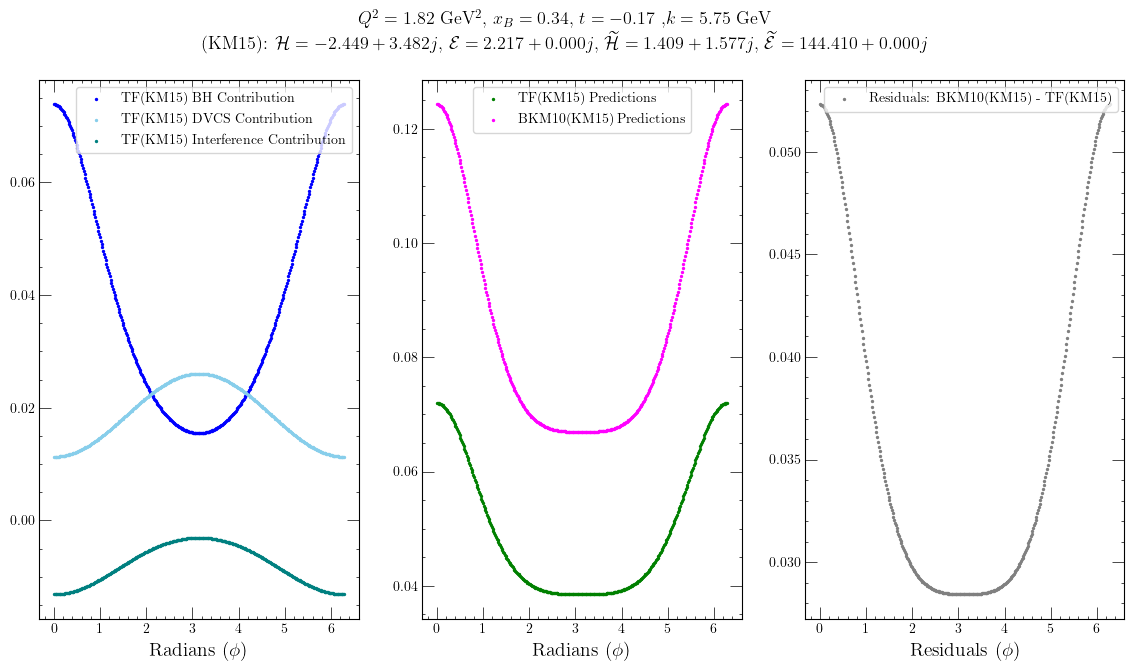

In [65]:
xsec_test_fig, xsec_test_ax = plt.subplots(1, 3, figsize = (14, 7))

# BH(XDJ)
# xsec_test_ax[0].scatter(
#     phi_array_in_radians, _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*TEST_X_BJORKEN*TEST_Y*bh_xdj / (16. * tf.square(tf.constant(np.pi)) * TEST_Q_SQUARED * tf.sqrt(1. + TEST_EP**2)),
#     color = "crimson", s = 2., label = "TF(XDJ) BH Contribution")

# BH(KM15)
xsec_test_ax[0].scatter(
    phi_array_in_radians, _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*TEST_X_BJORKEN*TEST_Y*bh_km15 / (16. * tf.square(tf.constant(np.pi)) * TEST_Q_SQUARED * tf.sqrt(1. + TEST_EP**2)),
    color = "blue", s = 2., label = "TF(KM15) BH Contribution")

# DVCS(XDJ)
# xsec_test_ax[0].scatter(
#     phi_array_in_radians, _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*TEST_X_BJORKEN*TEST_Y*dvcs_xdj / (16. * tf.square(tf.constant(np.pi)) * TEST_Q_SQUARED * tf.sqrt(1. + TEST_EP**2)), 
#     color = "red", s = 2., label = "TF(XDJ) DVCS Contribution")

    # DVCS(KM15)
xsec_test_ax[0].scatter(
    phi_array_in_radians, _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*TEST_X_BJORKEN*TEST_Y*dvcs_km15 / (16. * tf.square(tf.constant(np.pi)) * TEST_Q_SQUARED * tf.sqrt(1. + TEST_EP**2)), 
    color = "skyblue", s = 2., label = "TF(KM15) DVCS Contribution")

# I(XDJ)
# xsec_test_ax[0].scatter(
#     phi_array_in_radians, _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*TEST_X_BJORKEN*TEST_Y*interference_xdj / (16. * tf.square(tf.constant(np.pi)) * TEST_Q_SQUARED * tf.sqrt(1. + TEST_EP**2)), 
#     color = "brown", s = 2., label = "TF(XDJ) Interference Contribution")

# I(KM15)
xsec_test_ax[0].scatter(
    phi_array_in_radians, _CONVERSION_FACTOR*_QED_FINE_STRUCTURE**3*TEST_X_BJORKEN*TEST_Y*interference_km15 / (16. * tf.square(tf.constant(np.pi)) * TEST_Q_SQUARED * tf.sqrt(1. + TEST_EP**2)), 
    color = "teal", s = 2., label = "TF(KM15) Interference Contribution")

# SIGMA(BKM10(XDJ))
# xsec_test_ax[1].scatter(
#     phi_array_in_radians, tf_cross_section_xdj, 
#     color = "orange", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[1].scatter(
    phi_array_in_radians, tf_cross_section_km15, 
    color = "green", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(XDJ))
# xsec_test_ax[1].scatter(
#     phi_array_in_radians, bkm10_cross_sections_xdj, 
#     color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# SIGMA(BKM10(KM15))
xsec_test_ax[1].scatter(
    phi_array_in_radians, bkm10_cross_sections_km15, 
    color = "magenta", s = 2., label = "BKM10(KM15) Predictions")

# residuals
xsec_test_ax[2].scatter(
    phi_array_in_radians, (bkm10_cross_sections_km15 - tf_cross_section_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

# residuals
# xsec_test_ax[2].scatter(
#     phi_array_in_radians, (bkm10_cross_sections_xdj - tf_cross_section_xdj),
#     color = "darkgray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
# )

xsec_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
xsec_test_ax[2].set_xlabel(r"Residuals ($\phi$)", fontsize = 14)

xsec_test_ax[0].legend()
xsec_test_ax[1].legend()
xsec_test_ax[2].legend()

xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)
# xsec_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

#### (4.4.1): XDJ BSA Predictions [DEPRECATED]:

Computing XDJ bin predictions for BSA.

In [66]:
unp_target_plus_beam_bsa_bh_xdj = bh_squared(
    +1.0, 0.0,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)

unp_target_minus_beam_bsa_bh_xdj = bh_squared(
    -1.0, 0.0,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)

unp_target_plus_beam_bsa_dvcs_xdj = dvcs_squared(
    +1.0, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)

unp_target_minus_beam_bsa_dvcs_xdj = dvcs_squared(
    -1.0, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)

unp_target_plus_beam_bsa_interference_xdj = interference_amplitude(
    +1.0, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2, 
    TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E)

unp_target_minus_beam_bsa_interference_xdj = interference_amplitude(
    -1.0, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2, 
    TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E)

tf_unp_target_bsa_xdj = bkm10_bsa(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2,
    TEST_REAL_CFF_H, TEST_REAL_CFF_HT, TEST_REAL_CFF_E, TEST_REAL_CFF_ET, TEST_IM_CFF_H, TEST_IM_CFF_HT, TEST_IM_CFF_E, TEST_IM_CFF_ET)

#### (4.4.2): KM15 BSA Predictions:

Computing KM15 bin predictions for BSA.

In [67]:
unp_target_plus_beam_bsa_bh_km15 = bh_squared(
    +1.0, 0.0,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)
unp_target_minus_beam_bsa_bh_km15 = bh_squared(
    -1.0, 0.0,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_K, TEST_F1, TEST_F2, phi_array_in_radians, TEST_P1, TEST_P2)

unp_target_plus_beam_bsa_dvcs_km15 = dvcs_squared(
    +1.0, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

unp_target_minus_beam_bsa_dvcs_km15 = dvcs_squared(
    -1.0, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, phi_array_in_radians,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

unp_target_plus_beam_bsa_interference_km15 = interference_amplitude(
    +1.0, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2, 
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15)

unp_target_minus_beam_bsa_interference_km15 = interference_amplitude(
    -1.0, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2, 
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15)

tf_unp_target_bsa_km15 = bkm10_bsa(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
    TEST_Q_SQUARED, TEST_X_BJORKEN, TEST_T_VALUE, TEST_EP, TEST_Y, TEST_XI, TEST_K, TEST_F1, TEST_F2, TEST_K_TILDE, TEST_T_PRIME, phi_array_in_radians, TEST_P1, TEST_P2,
    CFF_REAL_H_KM15, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, CFF_IMAG_H_KM15, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

#### (4.4.3): Plotting BSA Predictions:

Text(0.5, 0.98, '$Q^2 = 1.82$ GeV$^2$, $x_B = 0.34$, $t = -0.17$ ,$k = 5.75$ GeV\n(KM15): $\\mathcal{H} = -2.449+3.482j$, $\\mathcal{E} = 2.217+0.000j$, $\\widetilde{\\mathcal{H}} = 1.409+1.577j$, $\\widetilde{\\mathcal{E}} = 144.410+0.000j$ ')

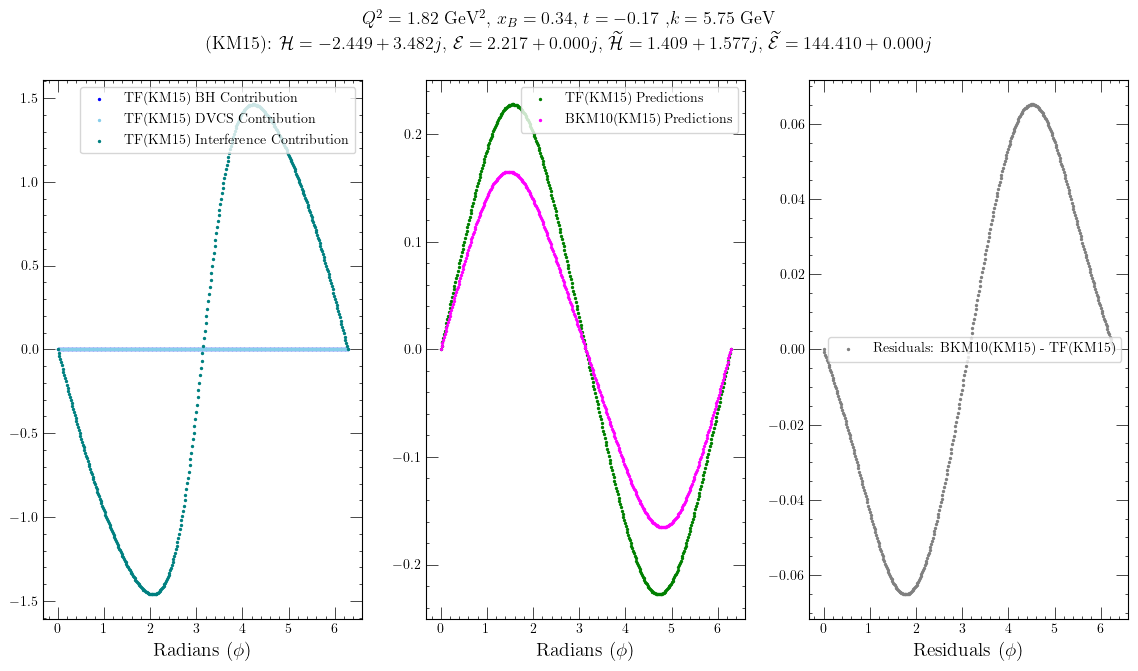

In [68]:
bsa_test_fig, bsa_test_ax = plt.subplots(1, 3, figsize = (14, 7))

# BH(XDJ)
# bsa_test_ax[0].scatter(
#     phi_array_in_radians, ((unp_target_plus_beam_bsa_bh_xdj - unp_target_minus_beam_bsa_bh_xdj) / (unp_target_plus_beam_bsa_bh_xdj + unp_target_minus_beam_bsa_bh_xdj)),
#     color = "crimson", s = 2., label = "TF(XDJ) BH Contribution")

# BH(KM15)
bsa_test_ax[0].scatter(
    phi_array_in_radians, ((unp_target_plus_beam_bsa_bh_km15 - unp_target_minus_beam_bsa_bh_km15) / (unp_target_plus_beam_bsa_bh_km15 + unp_target_minus_beam_bsa_bh_km15)),
    color = "blue", s = 2., label = "TF(KM15) BH Contribution")

# DVCS(XDJ)
# bsa_test_ax[0].scatter(
#     phi_array_in_radians, ((unp_target_plus_beam_bsa_dvcs_xdj - unp_target_minus_beam_bsa_dvcs_xdj) / (unp_target_plus_beam_bsa_dvcs_xdj + unp_target_minus_beam_bsa_dvcs_xdj)), 
#     color = "red", s = 2., label = "TF(XDJ) DVCS Contribution")

    # DVCS(KM15)
bsa_test_ax[0].scatter(
    phi_array_in_radians, ((unp_target_plus_beam_bsa_dvcs_km15 - unp_target_minus_beam_bsa_dvcs_km15) / (unp_target_plus_beam_bsa_dvcs_km15 + unp_target_minus_beam_bsa_dvcs_km15)), 
    color = "skyblue", s = 2., label = "TF(KM15) DVCS Contribution")

# I(XDJ)
# bsa_test_ax[0].scatter(
#     phi_array_in_radians, ((unp_target_plus_beam_bsa_interference_xdj - unp_target_minus_beam_bsa_interference_xdj) / (unp_target_plus_beam_bsa_interference_xdj + unp_target_minus_beam_bsa_interference_xdj)), 
#     color = "brown", s = 2., label = "TF(XDJ) Interference Contribution")

# I(KM15)
bsa_test_ax[0].scatter(
    phi_array_in_radians, ((unp_target_plus_beam_bsa_interference_km15 - unp_target_minus_beam_bsa_interference_km15) / (unp_target_plus_beam_bsa_interference_km15 + unp_target_minus_beam_bsa_interference_km15)), 
    color = "teal", s = 2., label = "TF(KM15) Interference Contribution")

# SIGMA(BKM10(XDJ))
# bsa_test_ax[1].scatter(
#     phi_array_in_radians, tf_unp_target_bsa_xdj, 
#     color = "orange", s = 2., label = "TF(XDJ) Predictions")

# SIGMA(BKM10(KM15))
bsa_test_ax[1].scatter(
    phi_array_in_radians, tf_unp_target_bsa_km15, 
    color = "green", s = 2., label = "TF(KM15) Predictions")

# SIGMA(BKM10(XDJ))
# bsa_test_ax[1].scatter(
#     phi_array_in_radians, bkm10_bsa_xdj, 
#     color = "purple", s = 2., label = "BKM10(XDJ) Predictions")

# SIGMA(BKM10(KM15))
bsa_test_ax[1].scatter(
    phi_array_in_radians, bkm10_bsa_km15, 
    color = "magenta", s = 2., label = "BKM10(KM15) Predictions")

# residuals
bsa_test_ax[2].scatter(
    phi_array_in_radians, (bkm10_bsa_km15 - tf_unp_target_bsa_km15),
    color = "gray", s = 2., label = "Residuals: BKM10(KM15) - TF(KM15)"
)

# residuals
# bsa_test_ax[2].scatter(
#     phi_array_in_radians, (bkm10_bsa_xdj - tf_unp_target_bsa_km15),
#     color = "darkgray", s = 2., label = "Residuals: BKM10(XDJ) - TF(XDJ)"
# )

bsa_test_ax[0].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
bsa_test_ax[1].set_xlabel(r"Radians ($\phi$)", fontsize = 14)
bsa_test_ax[2].set_xlabel(r"Residuals ($\phi$)", fontsize = 14)

bsa_test_ax[0].legend()
bsa_test_ax[1].legend()
bsa_test_ax[2].legend()

bsa_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}", fontsize = 13)
# bsa_test_fig.suptitle(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}", fontsize = 13)

### (4.4): Cross-Section Loss Function:

Here, we define a custom loss for the cross-section calculation. The main thing here is that it needs to be able to transform the model output into a different number to be able to check with the true values.

In [69]:
class CrossSectionLoss(tf.keras.losses.Loss):
    def __init__(self, name = "cross-section-loss"):
        super().__init__(name = name)
        
    def call(self, true_values, predicted_values):
        
        cff_h_real_tf = predicted_values[:, 0]
        cff_h_imag_tf = predicted_values[:, 1]
        t_tf = predicted_values[:, 2]
        xb_tf = predicted_values[:, 3]
        q_squared_tf = predicted_values[:, 4]
        phi_values = predicted_values[:, 5]

        fe_tf = compute_fe(t_tf)
        fg_tf = compute_fg(fe_tf) 
        f2_tf = compute_f2(t_tf, fe_tf, fg_tf)
        f1_tf = compute_f1(fg_tf, f2_tf)
        
        epsilon_tf = compute_epsilon(xb_tf, q_squared_tf)
        y_lep_tf = compute_y(TEST_BEAM_ENERGY, q_squared_tf, epsilon_tf)
        xi_tf = compute_skewness(xb_tf, t_tf, q_squared_tf)
        tmin_tf = compute_t_min(xb_tf, q_squared_tf, epsilon_tf)
        tprime_tf = compute_t_prime(t_tf, tmin_tf) # used in interference only
        ktilde_tf = compute_k_tilde(xb_tf, q_squared_tf, t_tf, tmin_tf, epsilon_tf)
        k_tf = compute_k(q_squared_tf, y_lep_tf, epsilon_tf, ktilde_tf)
        kdd_tf = compute_k_dot_delta(q_squared_tf, xb_tf, t_tf, phi_values, epsilon_tf, y_lep_tf, k_tf)
        p1_tf = prop_1(q_squared_tf, kdd_tf)
        p2_tf = prop_2(q_squared_tf, t_tf, kdd_tf)
            
        # make sure you know what CFFs are going in here...
        # bh_tf = bh_squared(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, k_tf, f1_tf, f2_tf, phi_values, p1_tf, p2_tf)
        # dvcs_tf = dvcs_squared(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, phi_values,
        #                     cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
        # interference_tf = interference_amplitude(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, f1_tf, f2_tf, ktilde_tf, tprime_tf, phi_values, p1_tf, p2_tf, 
        #                                       cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15)
        
        cross_section = bkm10_cross_section(
            TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
            q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, f1_tf, f2_tf, ktilde_tf, tprime_tf, phi_values, p1_tf, p2_tf,
            cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
        
        residuals = true_values - cross_section

        # square residuals
        squared_residuals = tf.square(residuals)

        # sum batch:
        mean_squared_error = tf.reduce_mean(squared_residuals)

        # return
        return mean_squared_error

#### (4.4.1): Testing the Cross Section Loss

[NOTE]: We are evaluating the BSA at $\phi = 2 \times \pi / 2$.

In [70]:
test_true_re_h_bkm10 = -0.897
test_true_im_h_bkm10 = 2.421

test_true_re_h_km15 = -2.449
test_true_im_h_km15 = 3.482

test_t = -0.17
test_xb = 0.34
test_q_squared = 1.82 

# case 1: correct values
predicted_values_1 = tf.constant([
    [test_true_re_h_bkm10, test_true_im_h_bkm10, test_t, test_xb, test_q_squared, 2.* 3.14 / 2.] # see [NOTE] above
    ], dtype = tf.float32)

# case 2: incorrect values
predicted_values_2 = tf.constant([
    [test_true_re_h_bkm10 + 0.1, test_true_im_h_bkm10 - 0.2, test_t, test_xb, test_q_squared, 2.* 3.14 / 2.] # see [NOTE] above
    ], dtype = tf.float32)


custom_loss = CrossSectionLoss()
loss_correct = custom_loss(bkm10_cross_sections_km15, predicted_values_1)
loss_wrong = custom_loss(bkm10_cross_sections_km15, predicted_values_2)

print(f"Correct loss value = {loss_correct.numpy()} vs. incorrect loss value = {loss_wrong.numpy()}")

test_fe = compute_fe(test_t)
test_fg = compute_fg(test_fe) 
test_f2 = compute_f2(test_t, test_fe, test_fg)
test_f1 = compute_f1(test_fg, test_f2)

test_epsilon = compute_epsilon(test_xb, test_q_squared)
test_y = compute_y(TEST_BEAM_ENERGY, test_q_squared, test_epsilon)
test_xi = compute_skewness(test_xb, test_t, test_q_squared)
test_tmin = compute_t_min(test_xb, test_q_squared, test_epsilon)
test_tprime = compute_t_prime(test_t, test_tmin)
test_ktilde = compute_k_tilde(test_xb, test_q_squared, test_t, test_tmin, test_epsilon)
test_k = compute_k(test_q_squared, test_y, test_epsilon, test_ktilde)

test_kdd = compute_k_dot_delta(test_q_squared, test_xb, test_t, x_training_phi_points, test_epsilon, test_y, test_k)
test_p1 = prop_1(test_q_squared, test_kdd)
test_p2 = prop_2(test_q_squared, test_t, test_kdd)

print(f'Computed FE = {test_fe} vs. true value = {TEST_FE} (residual = {np.abs(test_fe - TEST_FE)})')
print(f'Computed FG = {test_fg} vs. true value = {TEST_FE} (residual = {np.abs(test_fg - TEST_FG)})')
print(f'Computed F2 = {test_f2} vs. true value = {TEST_F2} (residual = {np.abs(test_f2 - TEST_F2)})')
print(f'Computed F1 = {test_f1} vs. true value = {TEST_F1} (residual = {np.abs(test_f1 - TEST_F1)})')

print(f'Computed epsilon = {test_epsilon} vs. true value = {TEST_EP} (residual = {np.abs(test_epsilon - TEST_EP)})')
print(f'Computed y = {test_y} vs. true value = {TEST_Y} (residual = {np.abs(test_y - TEST_Y)})')
print(f'Computed xi = {test_xi} vs. true value = {TEST_XI} (residual = {np.abs(test_xi - TEST_XI)})')
print(f'Computed tmin = {test_tmin} vs. true value = {TEST_T_MIN} (residual = {np.abs(test_tmin - TEST_T_MIN)})')
print(f'Computed tprime = {test_tprime} vs. true value = {TEST_T_PRIME} (residual = {np.abs(test_tprime - TEST_T_PRIME)})')
print(f'Computed ktilde = {test_ktilde} vs. true value = {TEST_K_TILDE} (residual = {np.abs(test_ktilde - TEST_K_TILDE)})')
print(f'Computed k = {test_k} vs. true value = {TEST_K} (residual = {np.abs(test_k - TEST_K)})')

print(f"Length of the TRAINING phi array: {len(x_training_phi_points)}")
print(f"Length of KDD computation: {len(test_kdd)}. Should be exact to TRAINING phi array: {len(test_kdd) == len(x_training_phi_points)}")
print(f"Length of P1 computation: {len(test_p1)}. Should be exact to TRAINING phi array: {len(test_kdd) == len(test_p1)}")
print(f"Length of P2 computation: {len(test_p2)}. Should be exact to TRAINING phi array: {len(test_kdd) == len(test_p2)}")

Correct loss value = 0.0033070994541049004 vs. incorrect loss value = 0.0033730340655893087
Computed FE = 0.6511852741241455 vs. true value = 0.6511853266961825 (residual = 5.960464477539063e-08)
Computed FG = 1.818661093711853 vs. true value = 0.6511853266961825 (residual = 1.1920928955078125e-07)
Computed F2 = 1.1137102842330933 vs. true value = 1.1137103937669304 (residual = 1.1920928955078125e-07)
Computed F1 = 0.7049508094787598 vs. true value = 0.7049508167585219 (residual = 0.0)
Computed epsilon = 0.47293558716773987 vs. true value = 0.47293561004973345 (residual = 2.9802322387695312e-08)
Computed y = 0.496096134185791 vs. true value = 0.49609612355928445 (residual = 0.0)
Computed xi = 0.1990618883714652 vs. true value = 0.19906188837146524 (residual = 2.7755575615628914e-17)
Computed tmin = -0.1355181783437729 vs. true value = -0.13551824472915253 (residual = 5.960464477539063e-08)
Computed tprime = -0.034481823444366455 vs. true value = -0.034481755270847486 (residual = 6.7055

### (4.5): BSA Loss Class

In [71]:
class BSALoss(tf.keras.losses.Loss):
    def __init__(self, name = "bsa-loss"):
        super().__init__(name = name)
        
    def call(self, true_bsa, predicted_values):
        
        cff_h_real_tf = predicted_values[:, 0]
        cff_h_imag_tf = predicted_values[:, 1]
        t_tf = predicted_values[:, 2]
        xb_tf = predicted_values[:, 3]
        q_squared_tf = predicted_values[:, 4]
        phi_values = predicted_values[:, 5]

        fe_tf = compute_fe(t_tf)
        fg_tf = compute_fg(fe_tf) 
        f2_tf = compute_f2(t_tf, fe_tf, fg_tf)
        f1_tf = compute_f1(fg_tf, f2_tf)
        
        epsilon_tf = compute_epsilon(xb_tf, q_squared_tf)
        y_lep_tf = compute_y(TEST_BEAM_ENERGY, q_squared_tf, epsilon_tf)
        xi_tf = compute_skewness(xb_tf, t_tf, q_squared_tf)
        tmin_tf = compute_t_min(xb_tf, q_squared_tf, epsilon_tf)
        tprime_tf = compute_t_prime(t_tf, tmin_tf) # used in interference only
        ktilde_tf = compute_k_tilde(xb_tf, q_squared_tf, t_tf, tmin_tf, epsilon_tf)
        k_tf = compute_k(q_squared_tf, y_lep_tf, epsilon_tf, ktilde_tf)
        kdd_tf = compute_k_dot_delta(q_squared_tf, xb_tf, t_tf, phi_values, epsilon_tf, y_lep_tf, k_tf)
        p1_tf = prop_1(q_squared_tf, kdd_tf)
        p2_tf = prop_2(q_squared_tf, t_tf, kdd_tf)
            
        # make sure you know what CFFs are going in here...
        bh_tf = bh_squared(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, k_tf, f1_tf, f2_tf, phi_values, p1_tf, p2_tf)
        dvcs_tf = dvcs_squared(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, phi_values,
                            cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
        interference_tf = interference_amplitude(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, f1_tf, f2_tf, ktilde_tf, tprime_tf, phi_values, p1_tf, p2_tf, 
                                              cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15)
        
        predicted_bsa = bkm10_bsa(
            TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
            q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, f1_tf, f2_tf, ktilde_tf, tprime_tf, phi_values, p1_tf, p2_tf,
            cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
        
        residuals = true_bsa - predicted_bsa

        # square residuals
        squared_residuals = tf.square(residuals)

        # sum batch:
        mean_squared_error = tf.reduce_mean(squared_residuals)

        # return
        return mean_squared_error

#### (4.5.1): Testing the BSA Loss

[NOTE]: We are evaluating the BSA at $\phi = 2 \times \pi / 2$.

In [72]:
test_true_re_h_bkm10 = -0.897
test_true_im_h_bkm10 = 2.421

test_true_re_h_km15 = -2.449
test_true_im_h_km15 = 3.482

test_t = -0.17
test_xb = 0.34
test_q_squared = 1.82 

# case 1: correct values
predicted_values_1 = tf.constant([
    [test_true_re_h_bkm10, test_true_im_h_bkm10, test_t, test_xb, test_q_squared, 2.* 3.14 / 2.]
    ], dtype = tf.float32)

# case 2: incorrect values
predicted_values_2 = tf.constant([
    [test_true_re_h_bkm10 + 0.1, test_true_im_h_bkm10 - 0.2, test_t, test_xb, test_q_squared, 2.* 3.14 / 2.]
    ], dtype = tf.float32)


custom_loss = BSALoss()
loss_correct = custom_loss(bkm10_bsa_km15, predicted_values_1)
loss_wrong = custom_loss(bkm10_bsa_km15, predicted_values_2)

print(f"Correct loss value = {loss_correct.numpy()} vs. incorrect loss value = {loss_wrong.numpy()}")

test_fe = compute_fe(test_t)
test_fg = compute_fg(test_fe) 
test_f2 = compute_f2(test_t, test_fe, test_fg)
test_f1 = compute_f1(test_fg, test_f2)

test_epsilon = compute_epsilon(test_xb, test_q_squared)
test_y = compute_y(TEST_BEAM_ENERGY, test_q_squared, test_epsilon)
test_xi = compute_skewness(test_xb, test_t, test_q_squared)
test_tmin = compute_t_min(test_xb, test_q_squared, test_epsilon)
test_tprime = compute_t_prime(test_t, test_tmin)
test_ktilde = compute_k_tilde(test_xb, test_q_squared, test_t, test_tmin, test_epsilon)
test_k = compute_k(test_q_squared, test_y, test_epsilon, test_ktilde)

test_kdd = compute_k_dot_delta(test_q_squared, test_xb, test_t, x_training_phi_points, test_epsilon, test_y, test_k)
test_p1 = prop_1(test_q_squared, test_kdd)
test_p2 = prop_2(test_q_squared, test_t, test_kdd)

print(f'Computed FE = {test_fe} vs. true value = {TEST_FE} (residual = {np.abs(test_fe - TEST_FE)})')
print(f'Computed FG = {test_fg} vs. true value = {TEST_FE} (residual = {np.abs(test_fg - TEST_FG)})')
print(f'Computed F2 = {test_f2} vs. true value = {TEST_F2} (residual = {np.abs(test_f2 - TEST_F2)})')
print(f'Computed F1 = {test_f1} vs. true value = {TEST_F1} (residual = {np.abs(test_f1 - TEST_F1)})')

print(f'Computed epsilon = {test_epsilon} vs. true value = {TEST_EP} (residual = {np.abs(test_epsilon - TEST_EP)})')
print(f'Computed y = {test_y} vs. true value = {TEST_Y} (residual = {np.abs(test_y - TEST_Y)})')
print(f'Computed xi = {test_xi} vs. true value = {TEST_XI} (residual = {np.abs(test_xi - TEST_XI)})')
print(f'Computed tmin = {test_tmin} vs. true value = {TEST_T_MIN} (residual = {np.abs(test_tmin - TEST_T_MIN)})')
print(f'Computed tprime = {test_tprime} vs. true value = {TEST_T_PRIME} (residual = {np.abs(test_tprime - TEST_T_PRIME)})')
print(f'Computed ktilde = {test_ktilde} vs. true value = {TEST_K_TILDE} (residual = {np.abs(test_ktilde - TEST_K_TILDE)})')
print(f'Computed k = {test_k} vs. true value = {TEST_K} (residual = {np.abs(test_k - TEST_K)})')

print(f"Length of the TRAINING phi array: {len(x_training_phi_points)}")
print(f"Length of KDD computation: {len(test_kdd)}. Should be exact to TRAINING phi array: {len(test_kdd) == len(x_training_phi_points)}")
print(f"Length of P1 computation: {len(test_p1)}. Should be exact to TRAINING phi array: {len(test_kdd) == len(test_p1)}")
print(f"Length of P2 computation: {len(test_p2)}. Should be exact to TRAINING phi array: {len(test_kdd) == len(test_p2)}")

Correct loss value = 0.012740136124193668 vs. incorrect loss value = 0.012740129604935646
Computed FE = 0.6511852741241455 vs. true value = 0.6511853266961825 (residual = 5.960464477539063e-08)
Computed FG = 1.818661093711853 vs. true value = 0.6511853266961825 (residual = 1.1920928955078125e-07)
Computed F2 = 1.1137102842330933 vs. true value = 1.1137103937669304 (residual = 1.1920928955078125e-07)
Computed F1 = 0.7049508094787598 vs. true value = 0.7049508167585219 (residual = 0.0)
Computed epsilon = 0.47293558716773987 vs. true value = 0.47293561004973345 (residual = 2.9802322387695312e-08)
Computed y = 0.496096134185791 vs. true value = 0.49609612355928445 (residual = 0.0)
Computed xi = 0.1990618883714652 vs. true value = 0.19906188837146524 (residual = 2.7755575615628914e-17)
Computed tmin = -0.1355181783437729 vs. true value = -0.13551824472915253 (residual = 5.960464477539063e-08)
Computed tprime = -0.034481823444366455 vs. true value = -0.034481755270847486 (residual = 6.705522

### (4.6): Simultaneous Fit Loss Class

In [73]:
class SimultaneousObservablesLoss(tf.keras.losses.Loss):
    def __init__(self, name = "simultaneous_observables_loss"):
        super().__init__(name = name)

        self._OBSERVABLE_WEIGHT_1 = 0.5
        self._OBSERVABLE_WEIGHT_2 = 0.5
        
    def call(self, true_values, predicted_values):
        
        cff_h_real_tf = predicted_values[:, 0]
        cff_h_imag_tf = predicted_values[:, 1]
        t_tf = predicted_values[:, 2]
        xb_tf = predicted_values[:, 3]
        q_squared_tf = predicted_values[:, 4]
        phi_values = predicted_values[:, 5]

        fe_tf = compute_fe(t_tf)
        fg_tf = compute_fg(fe_tf) 
        f2_tf = compute_f2(t_tf, fe_tf, fg_tf)
        f1_tf = compute_f1(fg_tf, f2_tf)
        
        epsilon_tf = compute_epsilon(xb_tf, q_squared_tf)
        y_lep_tf = compute_y(TEST_BEAM_ENERGY, q_squared_tf, epsilon_tf)
        xi_tf = compute_skewness(xb_tf, t_tf, q_squared_tf)
        tmin_tf = compute_t_min(xb_tf, q_squared_tf, epsilon_tf)
        tprime_tf = compute_t_prime(t_tf, tmin_tf) # used in interference only
        ktilde_tf = compute_k_tilde(xb_tf, q_squared_tf, t_tf, tmin_tf, epsilon_tf)
        k_tf = compute_k(q_squared_tf, y_lep_tf, epsilon_tf, ktilde_tf)
        kdd_tf = compute_k_dot_delta(q_squared_tf, xb_tf, t_tf, phi_values, epsilon_tf, y_lep_tf, k_tf)
        p1_tf = prop_1(q_squared_tf, kdd_tf)
        p2_tf = prop_2(q_squared_tf, t_tf, kdd_tf)
            
        # make sure you know what CFFs are going in here...
        # bh_tf = bh_squared(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, k_tf, f1_tf, f2_tf, phi_values, p1_tf, p2_tf)
        # dvcs_tf = dvcs_squared(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, phi_values,
        #                     cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
        # interference_tf = interference_amplitude(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, f1_tf, f2_tf, ktilde_tf, tprime_tf, phi_values, p1_tf, p2_tf, 
        #                                       cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15)

        true_cross_section = true_values[:, 0]
        true_bsa = true_values[:, 1]

        cross_section = bkm10_cross_section(
            TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
            q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, f1_tf, f2_tf, ktilde_tf, tprime_tf, phi_values, p1_tf, p2_tf,
            cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
        
        # compute cross-section residuals:
        residuals_cross_section = true_cross_section - cross_section

        predicted_bsa = bkm10_bsa(
            TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
            q_squared_tf, xb_tf, t_tf, epsilon_tf, y_lep_tf, xi_tf, k_tf, f1_tf, f2_tf, ktilde_tf, tprime_tf, phi_values, p1_tf, p2_tf,
            cff_h_real_tf, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag_tf, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
        
        # compute BSA residuals:
        residuals_bsa = true_bsa - predicted_bsa

        # compute the MSE:
        mean_squared_error = (
            self._OBSERVABLE_WEIGHT_1 * tf.reduce_mean(tf.square(residuals_cross_section)) + 
            self._OBSERVABLE_WEIGHT_2 * tf.reduce_mean(tf.square(residuals_bsa)))

        return mean_squared_error

#### (4.4.2): Testing the Simultaneous Fit Loss

In [74]:
test_true_re_h_bkm10 = -0.897
test_true_im_h_bkm10 = 2.421

test_true_re_h_km15 = -2.449
test_true_im_h_km15 = 3.482

test_t = -0.17
test_xb = 0.34
test_q_squared = 1.82 

# case 1: correct values
predicted_values_1 = tf.constant([
    [test_true_re_h_bkm10, test_true_im_h_bkm10, test_t, test_xb, test_q_squared, 2.* 3.14 / 2.]
    ], dtype = tf.float32)

# case 2: incorrect values
predicted_values_2 = tf.constant([
    [test_true_re_h_bkm10 + 0.1, test_true_im_h_bkm10 - 0.2, test_t, test_xb, test_q_squared, 2.* 3.14 / 2.]
    ], dtype = tf.float32)


custom_loss = SimultaneousObservablesLoss()
loss_correct = custom_loss(tf.constant([bkm10_cross_sections_km15, bkm10_bsa_km15]), predicted_values_1)
loss_wrong = custom_loss(tf.constant([bkm10_cross_sections_km15, bkm10_bsa_km15]), predicted_values_2)

print(f"Correct loss value = {loss_correct.numpy()} vs. incorrect loss value = {loss_wrong.numpy()}")

test_fe = compute_fe(test_t)
test_fg = compute_fg(test_fe) 
test_f2 = compute_f2(test_t, test_fe, test_fg)
test_f1 = compute_f1(test_fg, test_f2)

test_epsilon = compute_epsilon(test_xb, test_q_squared)
test_y = compute_y(TEST_BEAM_ENERGY, test_q_squared, test_epsilon)
test_xi = compute_skewness(test_xb, test_t, test_q_squared)
test_tmin = compute_t_min(test_xb, test_q_squared, test_epsilon)
test_tprime = compute_t_prime(test_t, test_tmin)
test_ktilde = compute_k_tilde(test_xb, test_q_squared, test_t, test_tmin, test_epsilon)
test_k = compute_k(test_q_squared, test_y, test_epsilon, test_ktilde)

test_kdd = compute_k_dot_delta(test_q_squared, test_xb, test_t, x_training_phi_points, test_epsilon, test_y, test_k)
test_p1 = prop_1(test_q_squared, test_kdd)
test_p2 = prop_2(test_q_squared, test_t, test_kdd)

print(f'Computed FE = {test_fe} vs. true value = {TEST_FE} (residual = {np.abs(test_fe - TEST_FE)})')
print(f'Computed FG = {test_fg} vs. true value = {TEST_FE} (residual = {np.abs(test_fg - TEST_FG)})')
print(f'Computed F2 = {test_f2} vs. true value = {TEST_F2} (residual = {np.abs(test_f2 - TEST_F2)})')
print(f'Computed F1 = {test_f1} vs. true value = {TEST_F1} (residual = {np.abs(test_f1 - TEST_F1)})')

print(f'Computed epsilon = {test_epsilon} vs. true value = {TEST_EP} (residual = {np.abs(test_epsilon - TEST_EP)})')
print(f'Computed y = {test_y} vs. true value = {TEST_Y} (residual = {np.abs(test_y - TEST_Y)})')
print(f'Computed xi = {test_xi} vs. true value = {TEST_XI} (residual = {np.abs(test_xi - TEST_XI)})')
print(f'Computed tmin = {test_tmin} vs. true value = {TEST_T_MIN} (residual = {np.abs(test_tmin - TEST_T_MIN)})')
print(f'Computed tprime = {test_tprime} vs. true value = {TEST_T_PRIME} (residual = {np.abs(test_tprime - TEST_T_PRIME)})')
print(f'Computed ktilde = {test_ktilde} vs. true value = {TEST_K_TILDE} (residual = {np.abs(test_ktilde - TEST_K_TILDE)})')
print(f'Computed k = {test_k} vs. true value = {TEST_K} (residual = {np.abs(test_k - TEST_K)})')

print(f"Length of the TRAINING phi array: {len(x_training_phi_points)}")
print(f"Length of KDD computation: {len(test_kdd)}. Should be exact to TRAINING phi array: {len(test_kdd) == len(x_training_phi_points)}")
print(f"Length of P1 computation: {len(test_p1)}. Should be exact to TRAINING phi array: {len(test_kdd) == len(test_p1)}")
print(f"Length of P2 computation: {len(test_p2)}. Should be exact to TRAINING phi array: {len(test_kdd) == len(test_p2)}")

Correct loss value = 0.006231239996850491 vs. incorrect loss value = 0.006250626407563686
Computed FE = 0.6511852741241455 vs. true value = 0.6511853266961825 (residual = 5.960464477539063e-08)
Computed FG = 1.818661093711853 vs. true value = 0.6511853266961825 (residual = 1.1920928955078125e-07)
Computed F2 = 1.1137102842330933 vs. true value = 1.1137103937669304 (residual = 1.1920928955078125e-07)
Computed F1 = 0.7049508094787598 vs. true value = 0.7049508167585219 (residual = 0.0)
Computed epsilon = 0.47293558716773987 vs. true value = 0.47293561004973345 (residual = 2.9802322387695312e-08)
Computed y = 0.496096134185791 vs. true value = 0.49609612355928445 (residual = 0.0)
Computed xi = 0.1990618883714652 vs. true value = 0.19906188837146524 (residual = 2.7755575615628914e-17)
Computed tmin = -0.1355181783437729 vs. true value = -0.13551824472915253 (residual = 5.960464477539063e-08)
Computed tprime = -0.034481823444366455 vs. true value = -0.034481755270847486 (residual = 6.705522

### (4.5): DNN Model Architecture:

In [75]:
def cff_h_model():
    initializer = tf.keras.initializers.RandomUniform(minval = -0.1, maxval = 0.1, seed = None)
    
    all_model_inputs = tf.keras.Input(shape = (4,), name = "input_values") 
    kinematic_inputs = tf.keras.layers.Lambda(lambda x: x[:, :3], name = 'input_kinematics')(all_model_inputs) # takes t, xb, qsquared

    # [NOTE]: ONLY kinematic inputs goes into the DNN!
    hidden = tf.keras.layers.Dense(10, kernel_initializer = initializer, activation = "relu")(kinematic_inputs)
    hidden = tf.keras.layers.Dense(10, kernel_initializer = initializer, activation = "relu")(hidden)
    hidden = tf.keras.layers.Dense(10, kernel_initializer = initializer, activation = "relu")(hidden)
    # hidden = tf.keras.layers.Dense(10, kernel_initializer = initializer, activation = "relu")(hidden)

    # linear activation is default activation if `activation` key is not specified: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense
    cff_outputs = tf.keras.layers.Dense(2, activation = "linear", name = "cff_h")(hidden) # Re[H] and Im[H]
    
    full_model_outputs = tf.keras.layers.Concatenate(name = "kinematics_and_cffs")(
        [cff_outputs, all_model_inputs])
    
    model = tf.keras.Model(
        inputs = all_model_inputs,
        outputs = full_model_outputs)

    model.compile(
        optimizer = tf.keras.optimizers.Adam(), 
        loss = SimultaneousObservablesLoss(),
        metrics = ["accuracy"])
    return model

## (5): Fitting the Model:

### (5.1): Get a TF Summary of the DNN Model:

In [ ]:
cff_h_model().summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_values        │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_kinematics    │ (None, 3)         │          0 │ input_values[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10)        │         40 │ input_kinematics… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 10)        │        110 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 10)        │        110 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cff_h (Dense)       │ (None, 2)         │         22 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kinematics_and_cffs │ (None, 6)         │          0 │ cff_h[0][0],      │
│ (Concatenate)       │                   │            │ input_values[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 282 (1.10 KB)

 Trainable params: 282 (1.10 KB)

 Non-trainable params: 0 (0.00 B)

: 

### (5.2): **Begin the Replica Method**

In [ ]:
NUMBER_OF_EPOCHS = 750
number_of_replicas = 25

for replica in range(number_of_replicas):

    dnn_model = cff_h_model()

    dnn_model_history = dnn_model.fit(
        x_training,
        y_training,
        validation_data = (x_validation, y_validation),
        epochs = NUMBER_OF_EPOCHS,
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor = 'val_loss',
                patience = 25, # stop if no improvement for 25 epochs
                restore_best_weights = True
            )
        ],
        batch_size = 32,
        verbose = 0
        )

    number_of_epochs_run = len(dnn_model_history.epoch)
    print(f"The model ran for {number_of_epochs_run} epochs before early stopping.")

    dnn_model.save(f"./version_{VERSION_NUMBER}/replicas/replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.keras")

    training_loss_data = dnn_model_history.history["loss"]
    validation_loss_data = dnn_model_history.history["val_loss"]

    loss, accuracy = dnn_model.evaluate(x_testing, y_testing, verbose = 1)
    print(f"Test Loss for Replica {replica + 1}: {loss}")
    print(f"Test Accuracy for Replica {replica + 1}: {accuracy}")

    curves_fig, curves_ax = plt.subplots(1, figsize = (8, 8))
    log_curves_fig, log_curves_ax = plt.subplots(1, figsize = (8, 8))

    curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.array([np.max(training_loss_data) for number in training_loss_data]), color = "red", label = "Initial Loss Value")
    curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.zeros(shape = (number_of_epochs_run)), color = "green", label = r"Loss $= 0$")
    curves_ax.plot(np.arange(0, number_of_epochs_run, 1), training_loss_data, color = "blue", label = "Training Loss")
    curves_ax.plot(np.arange(0, number_of_epochs_run, 1), validation_loss_data, color = "purple", label = "Validation Loss")

    log_curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.log(np.array([np.max(training_loss_data) for number in training_loss_data])), color = "red", label = "Initial Loss Value")
    log_curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.log(np.zeros(shape = (number_of_epochs_run)) + 1e-20), color = "green", label = r"Loss $= 0$")
    log_curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.log(training_loss_data), color = "blue", label = "Log Training Loss")
    log_curves_ax.plot(np.arange(0, number_of_epochs_run, 1), np.log(validation_loss_data), color = "purple", label = "Log Validation Loss")

    curves_ax.legend(fontsize = 15)
    log_curves_ax.legend(fontsize = 15)

    curves_ax.set_xlabel("Epoch", fontsize = 15)
    curves_ax.set_ylabel("MSE", fontsize = 15)
    curves_ax.set_title(f"Replica {replica + 1} Learning Curves\n(Eval. Loss $= {loss:.3f}$, Eval. Accuracy $= {accuracy:.3f})$", fontsize = 15)

    log_curves_ax.set_xlabel("Epoch", fontsize = 15)
    log_curves_ax.set_ylabel("Log MSE Loss", fontsize = 15)
    log_curves_ax.set_title(f"Replica {replica + 1} Learning Curves\n(Eval. Loss $= {loss:.3f}$, Eval. Accuracy $= {accuracy:.3f})$", fontsize = 15)

    curves_fig.savefig(f"./version_{VERSION_NUMBER}/learning_curves/lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.png")
    curves_fig.savefig(f"./version_{VERSION_NUMBER}/learning_curves/lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.eps")

    log_curves_fig.savefig(f"./version_{VERSION_NUMBER}/learning_curves/log_lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.png")
    log_curves_fig.savefig(f"./version_{VERSION_NUMBER}/learning_curves/log_lc_replica_{replica + 1}_v{MAJOR_MINOR_NUMBER}.eps")
    
    plt.close(curves_fig)
    plt.close(log_curves_fig)

    tf.keras.backend.clear_session()

The model ran for 74 epochs before early stopping.
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 1.6843e-04
Test Loss for Replica 1: 0.00016842664626892656
Test Accuracy for Replica 1: 1.0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The model ran for 154 epochs before early stopping.
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 1.6843e-04
Test Loss for Replica 2: 0.00016842919285409153
Test Accuracy for Replica 2: 1.0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The model ran for 105 epochs before early stopping.
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 1.0000 - loss: 1.6839e-04
Test Loss for Replica 3: 0.00016839482123032212
Test Accuracy for Replica 3: 1.0


...

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The model ran for 99 epochs before early stopping.
1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step - accuracy: 1.0000 - loss: 1.6836e-04
Test Loss for Replica 22: 0.0001683623413555324
Test Accuracy for Replica 22: 1.0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


The model ran for 78 epochs before early stopping.
1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step - accuracy: 1.0000 - loss: 1.6841e-04
Test Loss for Replica 23: 0.00016841181786730886
Test Accuracy for Replica 23: 1.0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


## (6): DNN Predictions:

### (6.1): Prepare Smooth Input Data:

In [75]:
range_of_t = np.linspace(x_training["t"].min(), x_training["t"].max())
range_of_t

array([-0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17,
       -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17,
       -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17,
       -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17,
       -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17, -0.17,
       -0.17, -0.17, -0.17, -0.17, -0.17])

In [76]:
range_of_x_b = np.linspace(x_training["x_b"].min(), x_training["x_b"].max())
range_of_x_b

array([0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34,
       0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34,
       0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34,
       0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34, 0.34,
       0.34, 0.34, 0.34, 0.34, 0.34, 0.34])

In [77]:
range_of_q_squared = np.linspace(x_training["q_squared"].min(), x_training["q_squared"].max())
range_of_q_squared

array([1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82,
       1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82,
       1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82,
       1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82, 1.82,
       1.82, 1.82, 1.82, 1.82, 1.82, 1.82])

In [78]:
replica_paths = sorted(glob.glob(f"./version_{VERSION_NUMBER}/replicas/replica_*_v{MAJOR_MINOR_NUMBER}.keras"))
replicas = [tf.keras.models.load_model(
    path,
    compile = False,
    safe_mode = False) for path in replica_paths]
print(f"Loaded {len(replicas)} replica models.")


Loaded 23 replica models.


In [79]:
# this is the entire dataset! (i.e. training+validation)
x_data = test_dataframe[["t", "x_b", "q_squared", "phi"]].values.astype(np.float32)

all_predictions = []

for replica in replicas:
    predicted_outputs = replica.predict(x_data) # predicting using x_data
    all_predictions.append(predicted_outputs)

all_predictions = np.array(all_predictions)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


Let's look at what is in `all_predictions`.

In [80]:
len(all_predictions)

23

In [81]:
all_predictions.shape

(23, 360, 6)

So, every array in `all_predictions` corresponds to a replica.

In [82]:
print(len(all_predictions[0]))
print(all_predictions[0].shape)

360
(360, 6)


Every replica array is another array with the number of datapoints we trained on. Then, at each datapoint, we have, in some order, probably the following one, $Re[\mathcal{H}]$, $Im[\mathcal{H}]$, $t$, $x_{\text{B}}$, and $Q^{2}$. Let's just print out an example to check.

In [83]:
all_predictions[0][5]

array([ 5.9198976 ,  4.794625  , -0.17      ,  0.34      ,  1.82      ,
        0.08750954], dtype=float32)

Yeah. It looks like it's two random numbers, then $t$, $x_{\text{B}}$, $Q^{2}$, then $\phi$ in radians.

### (6.5): Compute Cross-Section Across Replicas with $\mathcal{H}$ Prediction

#### (6.5.1): Make sure We Can Index the Right Data:

In [84]:
# should be replica #3's data:
all_predictions[2]

array([[ 5.906574  ,  4.7926755 , -0.17      ,  0.34      ,  1.82      ,
         0.        ],
       [ 5.906574  ,  4.7926755 , -0.17      ,  0.34      ,  1.82      ,
         0.01750191],
       [ 5.906574  ,  4.7926755 , -0.17      ,  0.34      ,  1.82      ,
         0.03500382],
       ...,
       [ 5.906574  ,  4.7926755 , -0.17      ,  0.34      ,  1.82      ,
         6.2481813 ],
       [ 5.906574  ,  4.792675  , -0.17      ,  0.34      ,  1.82      ,
         6.265683  ],
       [ 5.906574  ,  4.792675  , -0.17      ,  0.34      ,  1.82      ,
         6.2831855 ]], dtype=float32)

#### (6.5.2): Make Predictions for $d^{4}\sigma$ and $\text{BSA}$:

In [85]:
replicas_cross_predictions = []
replicas_bsa_predictions = []

for index, _ in enumerate(all_predictions):

    cff_h_real = all_predictions[index][:, 0] # getting Re[H]
    cff_h_imag = all_predictions[index][:, 1] # getting Im[H]
    t = all_predictions[index][:, 2] # getting t 
    xb = all_predictions[index][:, 3] # getting xb
    q_squared = all_predictions[index][:, 4] # getting Q^{2}
    phi = all_predictions[index][:, 5]

    fe = compute_fe(t)
    fg = compute_fg(fe) 
    f2 = compute_f2(t, fe, fg)
    f1 = compute_f1(fg, f2)
    
    epsilon = compute_epsilon(xb, q_squared)
    y_lep = compute_y(TEST_BEAM_ENERGY, q_squared, epsilon)
    xi = compute_skewness(xb, t, q_squared)
    tmin = compute_t_min(xb, q_squared, epsilon)
    tprime = compute_t_prime(t, tmin) # used in interference only
    ktilde = compute_k_tilde(xb, q_squared, t, tmin, epsilon)
    k = compute_k(q_squared, y_lep, epsilon, ktilde)
    kdd = compute_k_dot_delta(q_squared, xb, t, phi, epsilon, y_lep, k)
    p1 = prop_1(q_squared, kdd)
    p2 = prop_2(q_squared, t, kdd)
        
    # bh = bh_squared(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared, xb, t, epsilon, y_lep, k, f1, f2, phi, p1, p2)
    # dvcs = dvcs_squared(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared, xb, t, epsilon, y_lep, xi, k, phi,
    #                     cff_h_real, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)
    # interference = interference_amplitude(TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION, q_squared, xb, t, epsilon, y_lep, xi, k, f1, f2, ktilde, tprime, phi, p1, p2, 
    #                                           cff_h_real, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, cff_h_imag, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15)

    cross_section = bkm10_cross_section(
        TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
        q_squared, xb, t, epsilon, y_lep, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
        cff_h_real, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

    predicted_bsa = bkm10_bsa(
        TEST_LEPTON_HELICITY, TEST_TARGET_POLARIZATION,
        q_squared, xb, t, epsilon, y_lep, xi, k, f1, f2, ktilde, tprime, phi, p1, p2,
        cff_h_real, CFF_REAL_HT_KM15, CFF_REAL_E_KM15, CFF_REAL_ET_KM15, cff_h_imag, CFF_IMAG_HT_KM15, CFF_IMAG_E_KM15, CFF_IMAG_ET_KM15)

    replicas_cross_predictions.append(cross_section)
    replicas_bsa_predictions.append(predicted_bsa)

replicas_cross_predictions = np.array(replicas_cross_predictions)
replicas_bsa_predictions = np.array(replicas_bsa_predictions)

In [86]:
replicas_cross_predictions.shape

(23, 360)

Shape corresponds to the total number of predicted cross-sections across the total number of replicas. 

#### (6.5.3): Compute Replica Statistics for $d^{4}\sigma$:

In [87]:
mean_xs = np.mean(replicas_cross_predictions, axis = 0)
std_dev_xs = np.std(replicas_cross_predictions, axis = 0)

xs_mean = np.mean(replicas_cross_predictions, axis = 0)
xs_min = np.min(replicas_cross_predictions, axis = 0)
xs_max = np.max(replicas_cross_predictions, axis = 0)
xs_q1 = np.percentile(replicas_cross_predictions, 25, axis = 0)
xs_q3 = np.percentile(replicas_cross_predictions, 75, axis = 0)

xs_percentile_10 = np.percentile(replicas_cross_predictions, 10, axis = 0)
xs_percentile_20 = np.percentile(replicas_cross_predictions, 20, axis = 0)
xs_percentile_30 = np.percentile(replicas_cross_predictions, 30, axis = 0)
xs_percentile_40 = np.percentile(replicas_cross_predictions, 40, axis = 0)
xs_median = np.percentile(replicas_cross_predictions, 50, axis = 0)
xs_percentile_60 = np.percentile(replicas_cross_predictions, 60, axis = 0)
xs_percentile_70 = np.percentile(replicas_cross_predictions, 70, axis = 0)
xs_percentile_80 = np.percentile(replicas_cross_predictions, 80, axis = 0)
xs_percentile_90 = np.percentile(replicas_cross_predictions, 90, axis = 0)

The length of `mean_xs` should correspond to the total number of predicted cross sections; we integrated over the replicas.

In [88]:
mean_xs

array([0.13515705, 0.13514471, 0.13510764, 0.13504595, 0.13495976,
       0.13484906, 0.13471398, 0.13455482, 0.13437167, 0.13416465,
       0.13393426, 0.13368054, 0.1334039 , 0.13310462, 0.132783  ,
       0.13243955, 0.13207455, 0.13168837, 0.13128161, 0.13085456,
       0.13040777, 0.12994173, 0.12945682, 0.12895378, 0.12843288,
       0.12789488, 0.12734023, 0.12676948, 0.1261832 , 0.12558205,
       0.12496654, 0.1243372 , 0.12369477, 0.12303974, 0.12237275,
       0.12169437, 0.12100517, 0.12030583, 0.11959685, 0.1188789 ,
       0.11815251, 0.11741831, 0.11667681, 0.11592863, 0.11517435,
       0.11441441, 0.11364951, 0.11288007, 0.1121067 , 0.11132984,
       0.11055008, 0.10976782, 0.10898365, 0.10819796, 0.10741126,
       0.10662401, 0.10583662, 0.10504951, 0.10426316, 0.1034779 ,
       0.10269412, 0.10191225, 0.10113262, 0.1003556 , 0.09958154,
       0.09881078, 0.09804354, 0.0972802 , 0.09652111, 0.09576643,
       0.0950165 , 0.09427156, 0.09353182, 0.09279757, 0.09206

#### (6.5.4): Compute Replica Statistics for $\text{BSA}$:

In [89]:
mean_bsa = np.mean(replicas_bsa_predictions, axis = 0)
std_dev_bsa = np.std(replicas_bsa_predictions, axis = 0)

bsa_mean = np.mean(replicas_bsa_predictions, axis = 0)
bsa_min = np.min(replicas_bsa_predictions, axis = 0)
bsa_max = np.max(replicas_bsa_predictions, axis = 0)
bsa_q1 = np.percentile(replicas_bsa_predictions, 25, axis = 0)
bsa_q3 = np.percentile(replicas_bsa_predictions, 75, axis = 0)

bsa_percentile_10 = np.percentile(replicas_bsa_predictions, 10, axis = 0)
bsa_percentile_20 = np.percentile(replicas_bsa_predictions, 20, axis = 0)
bsa_percentile_30 = np.percentile(replicas_bsa_predictions, 30, axis = 0)
bsa_percentile_40 = np.percentile(replicas_bsa_predictions, 40, axis = 0)
bsa_median = np.percentile(replicas_bsa_predictions, 50, axis = 0)
bsa_percentile_60 = np.percentile(replicas_bsa_predictions, 60, axis = 0)
bsa_percentile_70 = np.percentile(replicas_bsa_predictions, 70, axis = 0)
bsa_percentile_80 = np.percentile(replicas_bsa_predictions, 80, axis = 0)
bsa_percentile_90 = np.percentile(replicas_bsa_predictions, 90, axis = 0)

Just checking out the array.

In [90]:
mean_bsa

array([-2.63636046e-08,  2.43614917e-03,  4.87194071e-03,  7.30686029e-03,
        9.74055938e-03,  1.21726617e-02,  1.46026621e-02,  1.70301925e-02,
        1.94548853e-02,  2.18762476e-02,  2.42938809e-02,  2.67074257e-02,
        2.91163791e-02,  3.15203555e-02,  3.39189805e-02,  3.63117233e-02,
        3.86982523e-02,  4.10780311e-02,  4.34507616e-02,  4.58158776e-02,
        4.81730327e-02,  5.05217202e-02,  5.28614633e-02,  5.51918596e-02,
        5.75125068e-02,  5.98228462e-02,  6.21224642e-02,  6.44108430e-02,
        6.66875467e-02,  6.89520761e-02,  7.12039471e-02,  7.34427124e-02,
        7.56677985e-02,  7.78787583e-02,  8.00750256e-02,  8.22561234e-02,
        8.44215751e-02,  8.65707695e-02,  8.87032673e-02,  9.08183977e-02,
        9.29157287e-02,  9.49946418e-02,  9.70546380e-02,  9.90950614e-02,
        1.01115420e-01,  1.03115104e-01,  1.05093524e-01,  1.07050046e-01,
        1.08984180e-01,  1.10895164e-01,  1.12782530e-01,  1.14645556e-01,
        1.16483666e-01,  

### (6.6): Figures of DNN $d^{4}\sigma$ Prediction

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


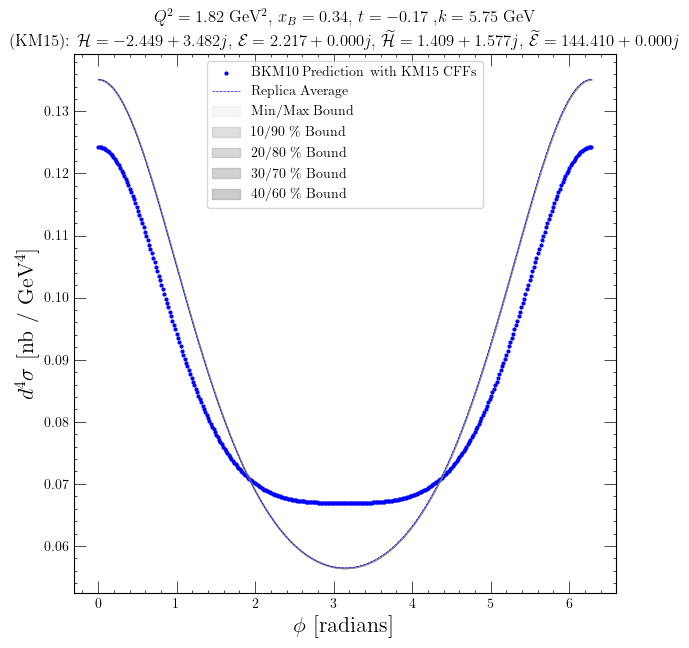

In [91]:
fig2, ax2 = plt.subplots(1, figsize = (7, 7))

ax2.scatter(
    phi_array_in_radians, bkm10_cross_sections_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

# ax2.scatter(
#     phi_array_in_radians, bkm10_cross_sections_xdj,
#     s = 4., label = "BKM10 Prediction with XDJ CFFs", color = "skyblue")

ax2.plot(
    phi_array_in_radians,
    mean_xs,
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_max,
    y2 = xs_min,
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_90,
    y2 = xs_percentile_10,
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_80,
    y2 = xs_percentile_20,
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_70,
    y2 = xs_percentile_30,
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

ax2.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_60,
    y2 = xs_percentile_40,
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

ax2.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
ax2.set_ylabel(r"$d^{4}\sigma$ [nb / GeV$^{4}$]", fontsize = 16)
ax2.set_title(f"{title_string}\n(KM15): {km15_cff_string}")
# ax2.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")

plt.legend()

fig2.savefig(f"./version_{VERSION_NUMBER}/plots/dnn_xsec_vs_phi_v{MAJOR_MINOR_NUMBER}.png")
fig2.savefig(f"./version_{VERSION_NUMBER}/plots/dnn_xsec_vs_phi_v{MAJOR_MINOR_NUMBER}.eps")

plt.show()
plt.close(fig2)

### (6.7): Figures of DNN $\text{BSA}$ Prediction

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


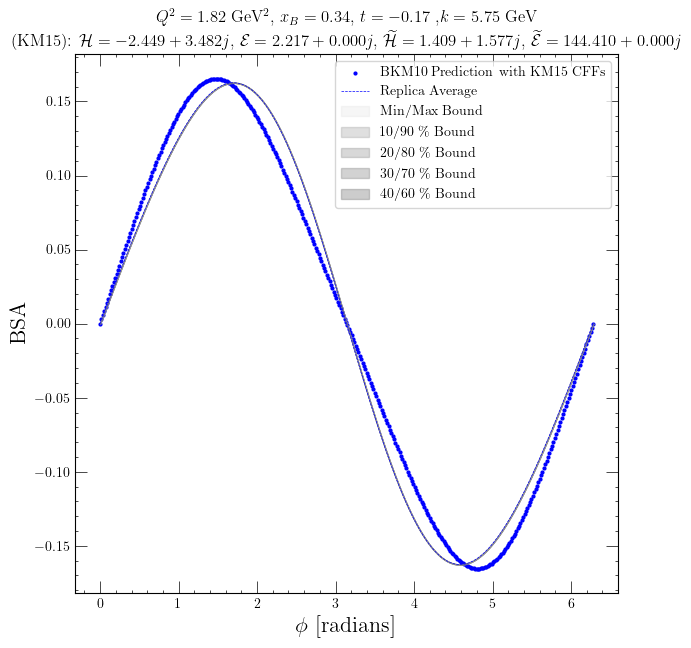

In [92]:
fig3, ax3 = plt.subplots(1, figsize = (7, 7))

ax3.scatter(
    phi_array_in_radians, bkm10_bsa_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

# ax3.scatter(
#     phi_array_in_radians, bkm10_bsa_xdj,
#     s = 4., label = "BKM10 Prediction with XDJ CFFs", color = "skyblue")

ax3.plot(
    phi_array_in_radians,
    mean_bsa,
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_max,
    y2 = bsa_min,
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_90,
    y2 = bsa_percentile_10,
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_80,
    y2 = bsa_percentile_20,
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_70,
    y2 = bsa_percentile_30,
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

ax3.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_60,
    y2 = bsa_percentile_40,
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

ax3.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
ax3.set_ylabel(r"BSA", fontsize = 16)
ax3.set_title(f"{title_string}\n(KM15): {km15_cff_string}")
# ax3.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")

plt.legend()

fig3.savefig(f"./version_{VERSION_NUMBER}/plots/dnn_bsa_vs_phi_v{MAJOR_MINOR_NUMBER}.png")
fig3.savefig(f"./version_{VERSION_NUMBER}/plots/dnn_bsa_vs_phi_v{MAJOR_MINOR_NUMBER}.eps")

plt.show()
plt.close(fig3)

### (6.8): Compute Mean $Re[\mathcal{H}]$ and $Im[\mathcal{H}]$ using Replicas:

What is the shape of the thing?

In [93]:
all_predictions.shape

(23, 360, 6)

Right. It goes `replica index, phi value, [Re[H], Im[H], t, xB, and Q squared]`.

We need to know if we are correctly obtaining the Re[$\mathcal{H}$] CFF using the array slicing below.

In [94]:
all_predictions[:, :, 0]

array([[5.9198976, 5.9198976, 5.9198976, ..., 5.9198976, 5.9198976,
        5.9198976],
       [5.9167004, 5.9167004, 5.9167004, ..., 5.9167004, 5.9167004,
        5.9167004],
       [5.906574 , 5.906574 , 5.906574 , ..., 5.906574 , 5.906574 ,
        5.906574 ],
       ...,
       [5.9122157, 5.9122157, 5.9122157, ..., 5.9122157, 5.9122157,
        5.9122157],
       [5.913522 , 5.913522 , 5.913522 , ..., 5.913522 , 5.913522 ,
        5.913522 ],
       [5.9130325, 5.9130325, 5.9130325, ..., 5.9130325, 5.9130325,
        5.9130325]], dtype=float32)

Seems like it's (almost) the same value across every array element. So, we can do an average across that dimension to obtain the representative value.

In [95]:
cff_h_real_pred_per_replica = np.mean(all_predictions[:, :, 0], axis = 1)
cff_h_imag_pred_per_replica = np.mean(all_predictions[:, :, 1], axis = 1)

In [96]:
cff_h_real_pred_per_replica

array([5.919898 , 5.9167004, 5.9065742, 5.9030485, 5.9086947, 5.9245844,
       5.908874 , 5.9142747, 5.9139447, 5.9150267, 5.9170527, 5.9131193,
       5.9129443, 5.917751 , 5.9129987, 5.9173393, 5.9172893, 5.9126906,
       5.913783 , 5.9215655, 5.912215 , 5.9135213, 5.913033 ],
      dtype=float32)

In [97]:
cff_h_imag_pred_per_replica

array([4.794625 , 4.797548 , 4.7926755, 4.7848086, 4.7877965, 4.8020563,
       4.7936935, 4.7961135, 4.7918253, 4.792892 , 4.791676 , 4.794029 ,
       4.793808 , 4.79707  , 4.795799 , 4.7913027, 4.794383 , 4.792065 ,
       4.7987366, 4.7957993, 4.799809 , 4.794402 , 4.7870545],
      dtype=float32)

In [98]:
cff_h_real_mean, cff_h_real_stddev = norm.fit(cff_h_real_pred_per_replica)
cff_h_imag_mean, cff_h_imag_stddev = norm.fit(cff_h_imag_pred_per_replica)

print(f"Re[H] mean of {cff_h_real_mean} and stdddev of {cff_h_real_stddev}")
print(f"Im[H] mean of {cff_h_imag_mean} and stdddev of {cff_h_imag_stddev}")

Re[H] mean of 5.914214611053467 and stdddev of 0.004640483763068914
Im[H] mean of 4.793911933898926 and stdddev of 0.0039010688196867704


### (6.9): Histogram for Re[$\mathcal{H}$] Values

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


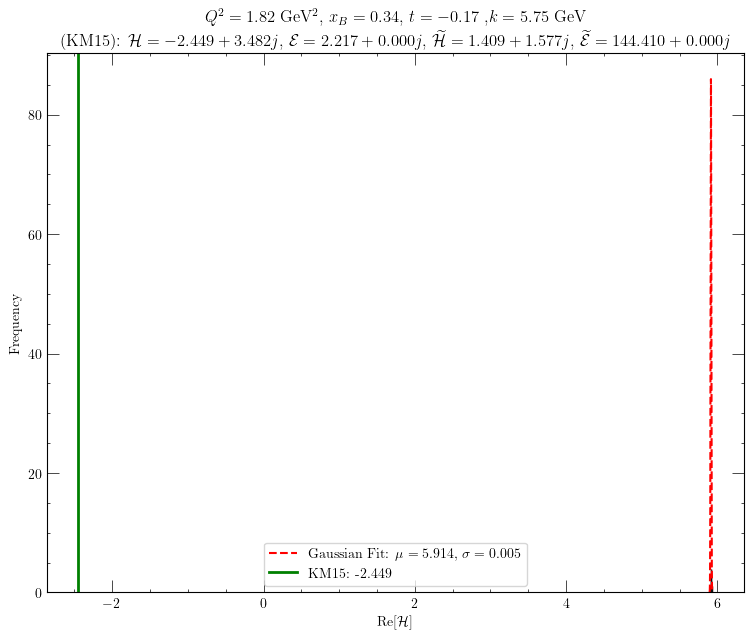

In [99]:
burner_x_values_cff_h_real = np.linspace(
    cff_h_real_mean - 4.*cff_h_real_stddev,
    cff_h_real_mean + 4.*cff_h_real_stddev,
    200)

fig4, ax4 = plt.subplots(1, 1, figsize = (9, 7))

ax4.hist(cff_h_real_pred_per_replica, bins = 30, alpha = 0.6, color = 'skyblue', edgecolor = 'black')
ax4.plot(
    burner_x_values_cff_h_real, norm.pdf(burner_x_values_cff_h_real, cff_h_real_mean, cff_h_real_stddev), 
    color = "red", linestyle = "--", label = fr"Gaussian Fit: $\mu = {cff_h_real_mean:.3f}$, $\sigma = {cff_h_real_stddev:.3f}$")
ax4.axvline(real_h_values[0], color = "green", linestyle = "-", linewidth = 2., label = f"KM15: {real_h_values[0]:.3f}")

ax4.set_ylabel("Frequency", rotation = 90.)
ax4.set_xlabel(r"Re$[\mathcal{H}]$")
ax4.set_title(f"{title_string}\n(KM15): {km15_cff_string}")
# ax4.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")

ax4.legend()


fig4.savefig(f"./version_{VERSION_NUMBER}/plots/cff_h_real_fits_v{MAJOR_MINOR_NUMBER}.png")
fig4.savefig(f"./version_{VERSION_NUMBER}/plots/cff_h_real_fits_v{MAJOR_MINOR_NUMBER}.eps")

plt.show()
plt.close(fig4)


### (6.10): Histogram for Im[$\mathcal{H}$] Values

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


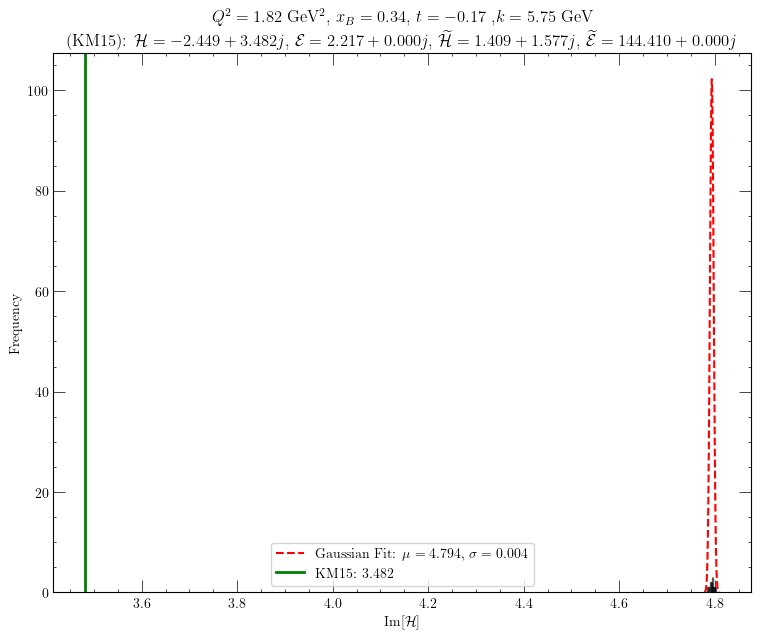

In [100]:
burner_x_values_cff_h_imag = np.linspace(
    cff_h_imag_mean - 4.*cff_h_imag_stddev,
    cff_h_imag_mean + 4.*cff_h_imag_stddev,
    200)

fig4, ax4 = plt.subplots(1, 1, figsize = (9, 7))

ax4.hist(cff_h_imag_pred_per_replica, bins = 30, alpha = 0.6, color = 'skyblue', edgecolor = 'black')
ax4.plot(
    burner_x_values_cff_h_imag, norm.pdf(burner_x_values_cff_h_imag, cff_h_imag_mean, cff_h_imag_stddev), 
    color = "red", linestyle = "--", label = fr"Gaussian Fit: $\mu = {cff_h_imag_mean:.3f}$, $\sigma = {cff_h_imag_stddev:.3f}$")
ax4.axvline(imag_h_values[0], color = "green", linestyle = "-", linewidth = 2., label = f"KM15: {imag_h_values[0]:.3f}")

ax4.set_ylabel("Frequency", rotation = 90.)
ax4.set_xlabel(r"Im$[\mathcal{H}]$")
ax4.set_title(f"{title_string}\n(KM15): {km15_cff_string}")

# ax4.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")
ax4.legend()


fig4.savefig(f"./version_{VERSION_NUMBER}/plots/cff_h_imag_fits_v{MAJOR_MINOR_NUMBER}.png")
fig4.savefig(f"./version_{VERSION_NUMBER}/plots/cff_h_imag_fits_v{MAJOR_MINOR_NUMBER}.eps")

plt.show()
plt.close(fig4)

## (7): Use Predicted CFF Values to Compare Observables:

### (7.1): Use Predicted $\mathcal{H}$ Values in BKM10 **Cross-Section and BSA** Prediction:

In [101]:
predicted_h_bkm10 = DifferentialCrossSection(
    configuration = {
        "kinematics": BKM10Inputs(
            lab_kinematics_k = TEST_BEAM_ENERGY,
            squared_Q_momentum_transfer = TEST_Q_SQUARED,
            x_Bjorken = TEST_X_BJORKEN,
            squared_hadronic_momentum_transfer_t = TEST_T_VALUE),
        "cff_inputs": CFFInputs(
            compton_form_factor_h = complex(cff_h_real_mean, cff_h_imag_mean),
            compton_form_factor_h_tilde = complex(TEST_REAL_CFF_HT, TEST_IM_CFF_HT),
            compton_form_factor_e = complex(TEST_REAL_CFF_E, TEST_IM_CFF_E),
            compton_form_factor_e_tilde = complex(TEST_REAL_CFF_ET, TEST_IM_CFF_ET)),
        "target_polarization": 0.0,
        "lepton_beam_polarization": 0.0,
        "using_ww": True
    },
    verbose = False,
    debugging = False)

bkm10_cross_sections_dnn = predicted_h_bkm10.compute_cross_section(phi_array_in_radians).real
bkm10_bsa_dnn = predicted_h_bkm10.compute_bsa(phi_array_in_radians).real

### (7.2): Overlay the $d^{4}\sigma$ Computed from DNN Fit of $\mathcal{H}$

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


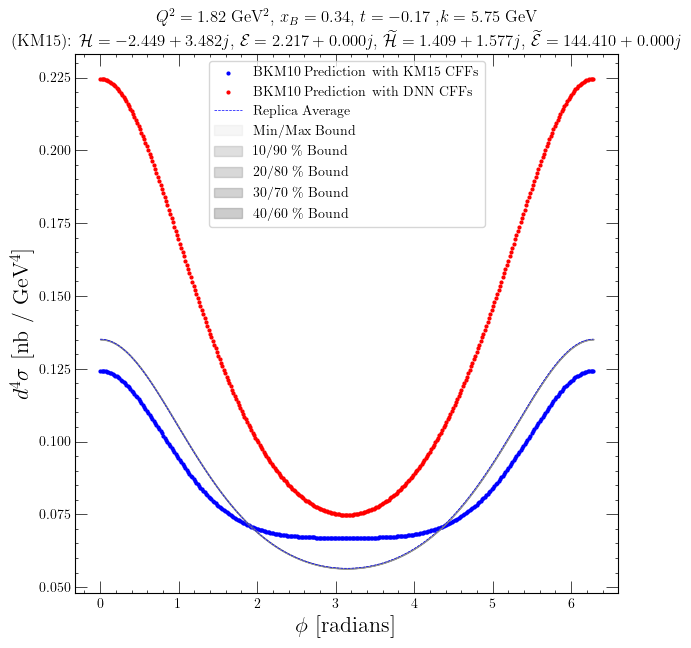

In [102]:
post_cff_fit_xsec_figure, post_cff_fit_xsec_axis = plt.subplots(1, figsize = (7, 7))

post_cff_fit_xsec_axis.scatter(
    phi_array_in_radians, bkm10_cross_sections_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

# post_cff_fit_xsec_axis.scatter(
#     phi_array_in_radians, bkm10_cross_sections_xdj,
#     s = 4., label = "BKM10 Prediction with XDJ CFFs", color = "skyblue")

post_cff_fit_xsec_axis.scatter(
    phi_array_in_radians, bkm10_cross_sections_dnn,
    s = 4., label = "BKM10 Prediction with DNN CFFs", color = "red")

post_cff_fit_xsec_axis.plot(
    phi_array_in_radians,
    mean_xs,
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

post_cff_fit_xsec_axis.fill_between(
    x = phi_array_in_radians,
    y1 = xs_max,
    y2 = xs_min,
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

post_cff_fit_xsec_axis.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_90,
    y2 = xs_percentile_10,
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

post_cff_fit_xsec_axis.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_80,
    y2 = xs_percentile_20,
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

post_cff_fit_xsec_axis.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_70,
    y2 = xs_percentile_30,
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

post_cff_fit_xsec_axis.fill_between(
    x = phi_array_in_radians,
    y1 = xs_percentile_60,
    y2 = xs_percentile_40,
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

post_cff_fit_xsec_axis.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
post_cff_fit_xsec_axis.set_ylabel(r"$d^{4}\sigma$ [nb / GeV$^{4}$]", fontsize = 16)
post_cff_fit_xsec_axis.set_title(f"{title_string}\n(KM15): {km15_cff_string}")
# post_cff_fit_xsec_axis.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")

plt.legend()

post_cff_fit_xsec_figure.savefig(f"./version_{VERSION_NUMBER}/plots/cross_section_comparison_v{MAJOR_MINOR_NUMBER}.png")
post_cff_fit_xsec_figure.savefig(f"./version_{VERSION_NUMBER}/plots/cross_section_comparison_v{MAJOR_MINOR_NUMBER}.eps")

plt.show()
plt.close(post_cff_fit_xsec_figure)

### (7.3): Overlay the $\text{BSA}$ Computed from DNN Fit of $\mathcal{H}$

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


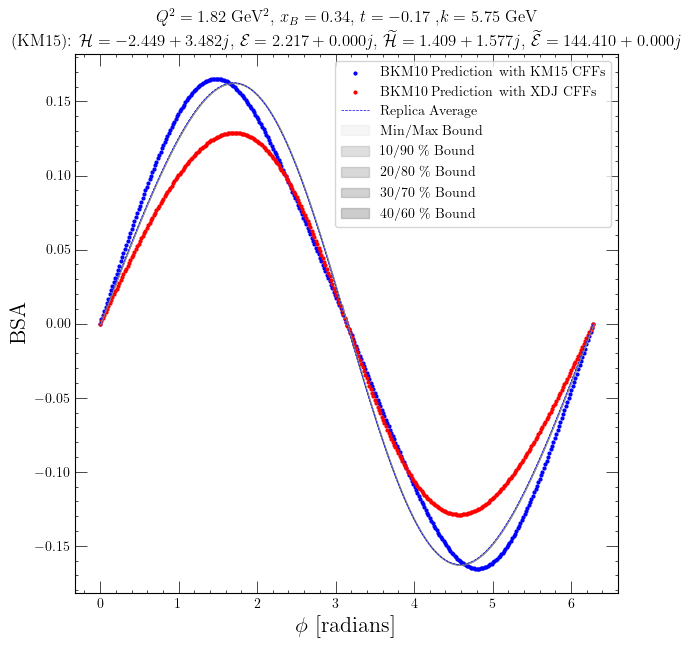

In [103]:
post_cff_fit_bsa_figure, post_cff_fit_bsa_axis = plt.subplots(1, figsize = (7, 7))

post_cff_fit_bsa_axis.scatter(
    phi_array_in_radians, bkm10_bsa_km15,
    s = 4., label = "BKM10 Prediction with KM15 CFFs", color = "blue")

# post_cff_fit_bsa_axis.scatter(
#     phi_array_in_radians, bkm10_bsa_xdj,
#     s = 4., label = "BKM10 Prediction with XDJ CFFs", color = "skyblue")

post_cff_fit_bsa_axis.scatter(
    phi_array_in_radians, bkm10_bsa_dnn,
    s = 4., label = "BKM10 Prediction with XDJ CFFs", color = "red")

post_cff_fit_bsa_axis.plot(
    phi_array_in_radians,
    mean_bsa,
    label = r'Replica Average',
    color = "blue",
    linewidth = 0.5,
    linestyle = 'dashed')

post_cff_fit_bsa_axis.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_max,
    y2 = bsa_min,
    label = r'Min/Max Bound',
    color = "lightgray",
    alpha = 0.2)

post_cff_fit_bsa_axis.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_90,
    y2 = bsa_percentile_10,
    label = r'10/90 \% Bound',
    color = "gray",
    alpha = 0.25)

post_cff_fit_bsa_axis.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_80,
    y2 = bsa_percentile_20,
    label = r'20/80 \% Bound',
    color = "gray",
    alpha = 0.3)

post_cff_fit_bsa_axis.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_70,
    y2 = bsa_percentile_30,
    label = r'30/70 \% Bound',
    color = "gray",
    alpha = 0.35)

post_cff_fit_bsa_axis.fill_between(
    x = phi_array_in_radians,
    y1 = bsa_percentile_60,
    y2 = bsa_percentile_40,
    label = r'40/60 \% Bound',
    color = "gray",
    alpha = 0.4)

post_cff_fit_bsa_axis.set_xlabel(r"$\phi$ [radians]", fontsize = 16)
post_cff_fit_bsa_axis.set_ylabel(r"BSA", fontsize = 16)
post_cff_fit_bsa_axis.set_title(f"{title_string}\n(KM15): {km15_cff_string}")
# post_cff_fit_bsa_axis.set_title(f"{title_string}\n(KM15): {km15_cff_string}\n(XDJ): {xdj_cff_string}")

plt.legend()

post_cff_fit_bsa_figure.savefig(f"./version_{VERSION_NUMBER}/plots/bsa_comparison_v{MAJOR_MINOR_NUMBER}.png")
post_cff_fit_bsa_figure.savefig(f"./version_{VERSION_NUMBER}/plots/bsa_comparison_v{MAJOR_MINOR_NUMBER}.eps")

plt.show()
plt.close(post_cff_fit_bsa_figure)